# ChartQA Pro Professional Chart Understanding Benchmark Analysis

## Executive Summary

**Dataset:** chartqapro_mini - Professional Chart Understanding and Numerical Reasoning  
**Total Samples:** 494 chart Q&A pairs per phase  
**Task:** Answer questions about professional charts requiring numerical accuracy and data extraction precision  
**Evaluation Metrics:** GT in Pred (PRIMARY), ANLS, Exact Match, Substring Match, Cosine Similarity

**Note:** This is an experimental dataset with some incomplete model coverage. Some models had empty predictions and were filtered out during evaluation.

## Benchmark Structure

### QA1 Series: OCR + VLM Pipeline (Two-Step)
**Strategy:** Separate OCR extraction → LLM answers question based on extracted text

- **QA1a:** Azure Intelligence OCR + GPT-5-mini QA (simple prompt)
- **QA1b:** Mistral Document AI OCR + GPT-5-mini QA (generic prompt)
- **QA1c:** Azure Intelligence OCR + GPT-5-mini QA (task-aware prompt)

**Model Format:** `{parsing_model}__{qa_model}` (e.g., `azure_intelligence__gpt-5-mini`)

### QA2 Series: VLM Parse + QA Pipeline (Single VLM)
**Strategy:** Same VLM does both parsing and question answering

- **QA2a:** GPT-5-mini does parsing + QA (CoT prompt)
- **QA2b:** GPT-5-nano does parsing + QA (generic + CoT)
- **QA2c:** Claude Sonnet does parsing + QA

**Model Format:** `{model}__{model}` (e.g., `claude_sonnet__claude_sonnet`)

### QA3 Series: Direct VQA (Vision-to-Answer)
**Strategy:** VLM sees image directly and answers question

- **QA3a:** Claude Sonnet direct VQA
- **QA3b:** GPT-5-mini, GPT-5-nano, Claude Sonnet direct VQA

**Model Format:** `{model}` (e.g., `claude_sonnet`)

## Key Metrics

**PRIMARY METRIC:**
- **GT in Pred (Ground Truth in Prediction):** Main metric for QA tasks - checks if ground truth string (lowercase) is contained in prediction (lowercase). This is the most important metric for evaluating whether the model's answer contains the correct information.

**SECONDARY METRICS:**
- **ANLS (Average Normalized Levenshtein Similarity):** Standard QA metric, accounts for small variations (higher is better, 1.0 = perfect)
  - Threshold: 0.5 (standard for VQA tasks)
  - Handles multiple ground truth answers
- **EM (Exact Match):** Binary exact match (1.0 = exact, 0.0 = no match)
- **Substring Match:** Checks if prediction is substring of any ground truth or vice versa
- **Cosine Similarity:** Semantic similarity using embeddings (higher is better, 1.0 = identical)

## Analysis Focus Areas

1. **Pipeline Comparison:** QA1 (OCR+VLM) vs QA2 (VLM parse+QA) vs QA3 (direct VQA)
2. **Numerical Accuracy:** Exact vs approximate answer precision for chart data
3. **Chart Type Performance:** Differences across chart types (if metadata available)
4. **Data Extraction Precision:** Accuracy on extracting specific values from visual charts
5. **Professional Chart Understanding:** Challenges specific to business/professional charts
6. **Model Comparison:** Trade-offs between speed and numerical reasoning accuracy

## Data Quality

⚠️ **Important:** This notebook identifies and filters out rows with:
- Empty predictions (blank or NaN values)
- Error values in error columns
- These rows are excluded from all metric calculations to ensure accurate evaluation

⚠️ **Experimental Dataset:** Some models have incomplete coverage with empty predictions that were filtered out during benchmarking.

## To Run This Analysis

1. Ensure consolidated data exists in `../../2_clean/chartqapro_mini/`
2. This notebook will load QA1a-QA3b results and generate:
   - GT in Pred, ANLS, EM, Substring Match calculations
   - Semantic similarity analysis
   - Model comparison visualizations
   - Numerical accuracy analysis
   - Sample-level analysis (easiest/hardest questions)
   - Phase strategy comparison

## 1. Imports and Metadata

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import sys
from pathlib import Path
from typing import List, Dict, Optional, Tuple
import warnings
warnings.filterwarnings('ignore')

# Progress bar for long operations
from tqdm.notebook import tqdm

# Add parent directory to path for imports
sys.path.insert(0, str(Path.cwd().parent.parent.parent))

# Import QA evaluation metrics
from ocr_vs_vlm.metrics.evaluation_metrics import (
    compute_anls,
    compute_exact_match,
    compute_substring_match,
    compute_ground_truth_in_prediction,
    compute_prediction_in_ground_truth
)

# Import embedding cache manager for efficient cosine similarity computation
from ocr_vs_vlm.metrics.embedding_cache import EmbeddingCacheManager

# Model ordering configuration for consistent display
MODEL_ORDER = ['azure_intelligence', 'mistral_document_ai', 'donut', 
               'gpt-5-nano', 'gpt-5-mini', 'claude_sonnet', 'claude_haiku']

def sort_models(models: List[str]) -> List[str]:
    """Sort models according to MODEL_ORDER."""
    def sort_key(model):
        # Extract base model name (remove __ suffix for QA1/QA2 phases)
        base_model = model.split('__')[-1] if '__' in model else model
        try:
            return MODEL_ORDER.index(base_model)
        except ValueError:
            return len(MODEL_ORDER)  # Unknown models go to the end
    return sorted(models, key=sort_key)

def get_model_display_name(model: str) -> str:
    """Get display name for model."""
    display_names = {
        'azure_intelligence': 'Azure Intelligence',
        'mistral_document_ai': 'Mistral Document AI',
        'donut': 'Donut',
        'gpt-5-nano': 'GPT-5 Nano',
        'gpt-5-mini': 'GPT-5 Mini',
        'claude_sonnet': 'Claude Sonnet',
        'claude_haiku': 'Claude Haiku'
    }
    # Handle composite model names (e.g., azure_intelligence__gpt-5-mini)
    if '__' in model:
        parts = model.split('__')
        return f"{display_names.get(parts[0], parts[0])} → {display_names.get(parts[1], parts[1])}"
    return display_names.get(model, model)


def get_phase_group(phase: str) -> str:
    """Get phase group (QA1, QA2, QA3, QA4)."""
    if phase.startswith('QA1'):
        return 'QA1 (OCR+VLM)'
    elif phase.startswith('QA2'):
        return 'QA2 (VLM Parse+QA)'
    elif phase.startswith('QA3'):
        return 'QA3 (Direct VQA)'
    elif phase.startswith('QA4'):
        return 'QA4 (Special)'
    return 'Unknown'

def get_phase_strategy(phase: str) -> str:
    """Alias for get_phase_group for consistency."""
    return get_phase_group(phase)

# Utility functions for QA analysis
def parse_ground_truths(gt_string: str) -> List[str]:
    """Parse ground_truths from JSON string to list, handling double-encoded JSON."""
    if pd.isna(gt_string):
        return []
    if isinstance(gt_string, list):
        return gt_string
    try:
        first_parse = json.loads(gt_string)
        if isinstance(first_parse, list):
            result = []
            for item in first_parse:
                if isinstance(item, str):
                    try:
                        inner_parse = json.loads(item)
                        if isinstance(inner_parse, list):
                            result.extend(inner_parse)
                        else:
                            result.append(str(inner_parse))
                    except (json.JSONDecodeError, TypeError):
                        result.append(item)
                else:
                    result.append(str(item))
            return result
        else:
            return [str(first_parse)]
    except (json.JSONDecodeError, TypeError):
        return [str(gt_string)]

def get_phase_group(phase: str) -> str:
    """Get phase group (QA1, QA2, QA3)."""
    if phase.startswith('QA1'):
        return 'QA1 (OCR+VLM)'
    elif phase.startswith('QA2'):
        return 'QA2 (VLM Parse+QA)'
    elif phase.startswith('QA3'):
        return 'QA3 (Direct VQA)'
    return 'Unknown'

def extract_qa_model(column_name: str, phase: str) -> str:
    """Extract QA model name from prediction column."""
    if phase.startswith('QA1') or phase.startswith('QA2'):
        # Format: prediction_parsing__qa or prediction_model__model
        parts = column_name.replace('prediction_', '').split('__')
        return parts[-1]  # Return QA model (second part)
    else:
        # Format: prediction_model
        return column_name.replace('prediction_', '')

def categorize_question_type(question: str) -> str:
    """Categorize question by first word."""
    first_word = str(question).lower().strip().split()[0] if question else ''
    types = {
        'what': 'What',
        'where': 'Where',
        'when': 'When',
        'who': 'Who',
        'how': 'How',
        'which': 'Which',
        'why': 'Why',
        'is': 'Yes/No',
        'are': 'Yes/No',
        'does': 'Yes/No',
        'can': 'Yes/No'
    }
    return types.get(first_word, 'Other')

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 100)
pd.set_option('display.width', 1000)

# Plotting style
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 11
sns.set_palette('husl')

print("✓ Libraries and QA evaluation metrics loaded successfully!")
print(f"✓ Model display order: {', '.join(MODEL_ORDER)}")


✓ Libraries and QA evaluation metrics loaded successfully!
✓ Model display order: azure_intelligence, mistral_document_ai, donut, gpt-5-nano, gpt-5-mini, claude_sonnet, claude_haiku


## 2. Dataset Explorer

Load all phase files and explore the ChartQA Pro dataset structure.

In [24]:
# Define paths
RESULTS_DIR = Path("../../2_clean/chartqapro_mini")

# Check available files
available_files = list(RESULTS_DIR.glob("*.csv"))
print("Available files:")
for f in sorted(available_files):
    print(f"  - {f.name}")

Available files:
  - QA1a.csv
  - QA1b.csv
  - QA1c.csv
  - QA2a.csv
  - QA2b.csv
  - QA2c.csv
  - QA3a.csv
  - QA3b.csv


In [25]:
# Dataset configuration
DATASET_NAME = "chartqapro_mini"

# Initialize embedding cache manager
# This will load any previously computed embeddings from 3_embeddings/
EMBEDDINGS_DIR = Path("../../3_embeddings")
embedding_manager = EmbeddingCacheManager(DATASET_NAME, EMBEDDINGS_DIR)

print(f"📁 Dataset: {DATASET_NAME}")
print(f"📂 Embeddings directory: {EMBEDDINGS_DIR.resolve()}")
if embedding_manager.cache:
    print(f"✅ Loaded cached embeddings for phases: {', '.join(embedding_manager.cache.keys())}")
else:
    print("⚠️ No cached embeddings found - will compute on first run and save for future use")

📁 Dataset: chartqapro_mini
📂 Embeddings directory: /Users/kenzabenkirane/Documents/GitHub/research-playground/ocr_vs_vlm/results/3_embeddings
✅ Loaded cached embeddings for phases: QA2c, QA2a, QA1a, QA2b, QA3b, QA1b, QA3a, QA1c


In [26]:
# Load results for each phase
phase_dfs = {}

# Standard QA phases for ChartQA Pro
STANDARD_PHASES = ['QA1a', 'QA1b', 'QA1c', 'QA2a', 'QA2b', 'QA2c', 'QA3a', 'QA3b']

for phase in STANDARD_PHASES:
    file_path = RESULTS_DIR / f"{phase}.csv"
    if file_path.exists():
        phase_dfs[phase] = pd.read_csv(file_path)
        print(f"{phase}: {phase_dfs[phase].shape[0]} samples, {phase_dfs[phase].shape[1]} columns")
    else:
        print(f"{phase}: Not available")

print(f"\nTotal phases loaded: {len(phase_dfs)}")

QA1a: 494 samples, 12 columns
QA1b: 494 samples, 12 columns
QA1c: 494 samples, 12 columns
QA2a: 494 samples, 16 columns
QA2b: 494 samples, 16 columns
QA2c: 494 samples, 12 columns
QA3a: 494 samples, 16 columns
QA3b: 494 samples, 16 columns

Total phases loaded: 8


In [27]:
# Inspect column names for each phase
for phase, df in phase_dfs.items():
    print(f"\n{phase} columns:")
    pred_cols = [col for col in df.columns if col.startswith('prediction_')]
    models = [col.replace('prediction_', '') for col in pred_cols]
    print(f"  Models: {', '.join(models)}")
    print(f"  Question column: {'question' if 'question' in df.columns else 'NOT FOUND'}")
    print(f"  Ground truths column: {'ground_truths' if 'ground_truths' in df.columns else 'NOT FOUND'}")
    print(f"  Total columns: {len(df.columns)}")


QA1a columns:
  Models: azure_intelligence__gpt-5-mini, mistral_document_ai__gpt-5-mini
  Question column: question
  Ground truths column: ground_truths
  Total columns: 12

QA1b columns:
  Models: azure_intelligence__gpt-5-mini, mistral_document_ai__gpt-5-mini
  Question column: question
  Ground truths column: ground_truths
  Total columns: 12

QA1c columns:
  Models: azure_intelligence__gpt-5-mini, mistral_document_ai__gpt-5-mini
  Question column: question
  Ground truths column: ground_truths
  Total columns: 12

QA2a columns:
  Models: claude_sonnet__claude_sonnet, gpt-5-mini__gpt-5-mini, gpt-5-nano__gpt-5-nano
  Question column: question
  Ground truths column: ground_truths
  Total columns: 16

QA2b columns:
  Models: claude_sonnet__claude_sonnet, gpt-5-mini__gpt-5-mini, gpt-5-nano__gpt-5-nano
  Question column: question
  Ground truths column: ground_truths
  Total columns: 16

QA2c columns:
  Models: claude_sonnet__claude_sonnet, gpt-5-nano__gpt-5-nano
  Question column: qu

In [28]:
# Function to identify valid rows (exclude empty predictions and errors)
def is_valid_row(row, pred_col, err_col=None):
    """Check if a row has valid prediction (non-empty, no error)."""
    # Check if prediction is empty
    pred_value = row[pred_col]
    if pd.isna(pred_value) or str(pred_value).strip() == "":
        return False
    
    # Check if there's an error column and it has an error
    if err_col and err_col in row.index:
        if pd.notna(row[err_col]) and str(row[err_col]).strip() != "":
            return False
    
    return True

# Assess data quality for all phases
print("=" * 120)
print("DATA QUALITY ASSESSMENT")
print("=" * 120)

quality_stats = []

for phase, df in phase_dfs.items():
    print(f"\n📊 {phase} - Total rows: {len(df)}")
    
    pred_cols = [col for col in df.columns if col.startswith('prediction_')]
    
    for pred_col in pred_cols:
        model = pred_col.replace('prediction_', '')
        err_col = f'error_{model}'
        
        # Count valid and invalid rows
        empty_count = 0
        error_count = 0
        valid_count = 0
        
        for _, row in df.iterrows():
            if is_valid_row(row, pred_col, err_col):
                valid_count += 1
            else:
                # Check what type of invalid
                if pd.isna(row[pred_col]) or str(row[pred_col]).strip() == "":
                    empty_count += 1
                elif err_col in df.columns and pd.notna(row[err_col]):
                    error_count += 1
        
        invalid_count = empty_count + error_count
        valid_pct = (valid_count / len(df)) * 100
        
        print(f"  {model}:")
        print(f"    ✅ Valid rows: {valid_count}/{len(df)} ({valid_pct:.1f}%)")
        if invalid_count > 0:
            print(f"    ⚠️  Empty predictions: {empty_count}")
            if error_count > 0:
                print(f"    ❌ Errors logged: {error_count}")
        
        quality_stats.append({
            'Phase': phase,
            'Model': model,
            'Total Rows': len(df),
            'Valid Rows': valid_count,
            'Empty Predictions': empty_count,
            'Errors': error_count,
            'Valid %': valid_pct
        })

# Create summary DataFrame
quality_df = pd.DataFrame(quality_stats)

print("\n" + "=" * 120)
print("QUALITY SUMMARY - Models with Issues")
print("=" * 120)

# Show only models with issues
issues_df = quality_df[quality_df['Valid %'] < 100].sort_values('Valid %')
if len(issues_df) > 0:
    display(issues_df)
    print(f"\n⚠️  Found {len(issues_df)} model-phase combinations with data quality issues")
    print("These rows will be EXCLUDED from all metric calculations")
else:
    print("✅ All models have 100% valid data - no filtering needed!")

print("\n" + "=" * 120)

DATA QUALITY ASSESSMENT

📊 QA1a - Total rows: 494
  azure_intelligence__gpt-5-mini:
    ✅ Valid rows: 366/494 (74.1%)
    ⚠️  Empty predictions: 128
  mistral_document_ai__gpt-5-mini:
    ✅ Valid rows: 427/494 (86.4%)
    ⚠️  Empty predictions: 67

📊 QA1b - Total rows: 494
  azure_intelligence__gpt-5-mini:
    ✅ Valid rows: 390/494 (78.9%)
    ⚠️  Empty predictions: 104
  mistral_document_ai__gpt-5-mini:
    ✅ Valid rows: 429/494 (86.8%)
    ⚠️  Empty predictions: 65

📊 QA1c - Total rows: 494
  azure_intelligence__gpt-5-mini:
    ✅ Valid rows: 370/494 (74.9%)
    ⚠️  Empty predictions: 124
  mistral_document_ai__gpt-5-mini:
    ✅ Valid rows: 436/494 (88.3%)
    ⚠️  Empty predictions: 58

📊 QA2a - Total rows: 494
  claude_sonnet__claude_sonnet:
    ✅ Valid rows: 0/494 (0.0%)
    ⚠️  Empty predictions: 494
  gpt-5-mini__gpt-5-mini:
    ✅ Valid rows: 439/494 (88.9%)
    ⚠️  Empty predictions: 55
  gpt-5-nano__gpt-5-nano:
    ✅ Valid rows: 250/494 (50.6%)
    ⚠️  Empty predictions: 244

📊 

,Phase,Model,Total Rows,Valid Rows,Empty Predictions,Errors,Valid %
9,QA2b,claude_sonnet__claude_sonnet,494,0,494,0,0.000000
17,QA3b,claude_sonnet__claude_sonnet,494,0,494,0,0.000000
14,QA3a,claude_sonnet__claude_sonnet,494,0,494,0,0.000000
12,QA2c,claude_sonnet__claude_sonnet,494,0,494,0,0.000000
6,QA2a,claude_sonnet__claude_sonnet,494,0,494,0,0.000000
8,QA2a,gpt-5-nano__gpt-5-nano,494,250,244,0,50.607287
13,QA2c,gpt-5-nano__gpt-5-nano,494,272,222,0,55.060729
11,QA2b,gpt-5-nano__gpt-5-nano,494,274,220,0,55.465587
0,QA1a,azure_intelligence__gpt-5-mini,494,366,128,0,74.089069
4,QA1c,azure_intelligence__gpt-5-mini,494,370,124,0,74.898785



⚠️  Found 19 model-phase combinations with data quality issues
These rows will be EXCLUDED from all metric calculations



## 2.5 Data Quality Assessment ⚠️

**Critical Step:** Identify and filter out rows with empty predictions or errors to ensure accurate metrics.

## 3. Dataset Statistics

Analyze question and answer characteristics.

In [29]:
# Basic statistics for first available phase
phase_to_display = list(phase_dfs.keys())[0] if phase_dfs else None

if phase_to_display:
    print(f"\nBasic statistics for phase {phase_to_display}:")
    df_base = phase_dfs[phase_to_display]
    
    print("Dataset Statistics:")
    print(f"  Total samples: {len(df_base)}")
    
    if 'question' in df_base.columns:
        # Question length statistics
        question_lengths = df_base['question'].astype(str).str.len()
        question_word_counts = df_base['question'].astype(str).str.split().str.len()
        
        print(f"\nQuestion Length (characters):")
        print(f"  Mean: {question_lengths.mean():.1f} characters")
        print(f"  Median: {question_lengths.median():.1f} characters")
        print(f"  Min: {question_lengths.min()} characters")
        print(f"  Max: {question_lengths.max()} characters")
        
        print(f"\nQuestion Length (words):")
        print(f"  Mean: {question_word_counts.mean():.1f} words")
        print(f"  Median: {question_word_counts.median():.1f} words")
        
    if 'ground_truths' in df_base.columns:
        # Answer length statistics
        df_base['parsed_gt'] = df_base['ground_truths'].apply(parse_ground_truths)
        df_base['num_ground_truths'] = df_base['parsed_gt'].apply(len)
        df_base['avg_answer_length'] = df_base['parsed_gt'].apply(
            lambda gts: np.mean([len(str(gt)) for gt in gts]) if gts else 0
        )
        
        print(f"\nGround Truth Answer Statistics:")
        print(f"  Mean answers per question: {df_base['num_ground_truths'].mean():.2f}")
        print(f"  Median answers per question: {df_base['num_ground_truths'].median():.0f}")
        print(f"  Max answers for a single question: {df_base['num_ground_truths'].max():.0f}")
        
        print(f"\nAverage Answer Length (characters):")
        print(f"  Mean: {df_base['avg_answer_length'].mean():.1f} characters")
        print(f"  Median: {df_base['avg_answer_length'].median():.1f} characters")
        print(f"  Min: {df_base['avg_answer_length'].min():.1f} characters")
        print(f"  Max: {df_base['avg_answer_length'].max():.1f} characters")


Basic statistics for phase QA1a:
Dataset Statistics:
  Total samples: 494

Question Length (characters):
  Mean: 141.6 characters
  Median: 116.0 characters
  Min: 39 characters
  Max: 510 characters

Question Length (words):
  Mean: 23.1 words
  Median: 19.0 words

Ground Truth Answer Statistics:
  Mean answers per question: 1.00
  Median answers per question: 1
  Max answers for a single question: 1

Average Answer Length (characters):
  Mean: 14.7 characters
  Median: 9.0 characters
  Min: 5.0 characters
  Max: 134.0 characters


## 4. Sample Preview

Display 10 random Q&A samples from 3 different models.

In [30]:
# Import for incremental saving
from ocr_vs_vlm.metrics.embedding_cache import save_embeddings_for_phase

# Function to calculate QA metrics for a single prediction
def calculate_qa_metrics(
    prediction: str,
    ground_truths: List[str],
    phase: str,
    sample_id: str,
    model: str,
    emb_manager: EmbeddingCacheManager
) -> Dict[str, float]:
    """Calculate all QA metrics for a single sample with cached embeddings."""
    if pd.isna(prediction) or prediction == "" or not ground_truths:
        return {
            'gt_in_pred': 0.0,  # PRIMARY METRIC FIRST
            'anls': 0.0,
            'exact_match': 0.0,
            'substring_match': 0.0,
            'pred_in_gt': 0.0,
            'cosine_similarity': 0.0,
        }
    
    pred_str = str(prediction)
    
    # Compute cosine similarity with first ground truth
    cosine_sim = emb_manager.compute_cosine_similarity(
        phase=phase,
        ground_truth=ground_truths[0],
        prediction=pred_str,
        sample_id=sample_id,
        model=model
    )
    
    return {
        'gt_in_pred': compute_ground_truth_in_prediction(pred_str, ground_truths),  # PRIMARY METRIC FIRST
        'anls': compute_anls(pred_str, ground_truths, threshold=0.5),
        'exact_match': compute_exact_match(pred_str, ground_truths),
        'substring_match': compute_substring_match(pred_str, ground_truths),
        'pred_in_gt': compute_prediction_in_ground_truth(pred_str, ground_truths),
        'cosine_similarity': cosine_sim,
    }

# Calculate metrics for all phases and models
metrics_results = {}

for phase, df in phase_dfs.items():
    print(f"\n📊 Calculating metrics for {phase}...")
    
    # Get all prediction columns
    pred_cols = [col for col in df.columns if col.startswith('prediction_')]
    
    phase_metrics = {}
    
    for pred_col in pred_cols:
        model = pred_col.replace('prediction_', '')
        err_col = f'error_{model}'
        
        print(f"   Processing model: {model}")
        
        # Filter to only valid rows
        valid_rows = []
        for _, row in df.iterrows():
            if is_valid_row(row, pred_col, err_col):
                valid_rows.append(row)
        
        print(f"   Using {len(valid_rows)}/{len(df)} valid rows (excluding {len(df)-len(valid_rows)} empty/error rows)")
        
        if len(valid_rows) == 0:
            print(f"   ⚠️  No valid rows for {model} in {phase} - skipping")
            continue
        
        # Calculate metrics for each valid sample with progress bar
        metrics_list = []
        for row in tqdm(valid_rows, desc=f"   {model}", leave=False):
            ground_truths = parse_ground_truths(row['ground_truths'])
            metrics = calculate_qa_metrics(
                prediction=row[pred_col],
                ground_truths=ground_truths,
                phase=phase,
                sample_id=row['sample_id'],
                model=model,
                emb_manager=embedding_manager
            )
            metrics_list.append(metrics)
        
        # Aggregate metrics (PRIMARY METRIC FIRST)
        phase_metrics[model] = {
            'gt_in_pred': np.mean([m['gt_in_pred'] for m in metrics_list]),  # PRIMARY
            'gt_in_pred_std': np.std([m['gt_in_pred'] for m in metrics_list]),
            'anls': np.mean([m['anls'] for m in metrics_list]),
            'anls_std': np.std([m['anls'] for m in metrics_list]),
            'exact_match': np.mean([m['exact_match'] for m in metrics_list]),
            'exact_match_std': np.std([m['exact_match'] for m in metrics_list]),
            'substring_match': np.mean([m['substring_match'] for m in metrics_list]),
            'pred_in_gt': np.mean([m['pred_in_gt'] for m in metrics_list]),
            'cosine_similarity': np.mean([m['cosine_similarity'] for m in metrics_list]),
            'valid_samples': len(valid_rows),
            'total_samples': len(df),
        }
        
        print(f"   ✅ {model}: GT_in_Pred={phase_metrics[model]['gt_in_pred']:.4f} [PRIMARY], ANLS={phase_metrics[model]['anls']:.4f}, EM={phase_metrics[model]['exact_match']:.4f}")
    
    metrics_results[phase] = phase_metrics
    
    # Save embeddings incrementally after each phase completes
    if phase in embedding_manager.modified_phases:
        print(f"   💾 Saving embeddings for {phase}...")
        saved_file = save_embeddings_for_phase(
            dataset_name=DATASET_NAME,
            phase=phase,
            embeddings_dict=embedding_manager.cache[phase],
            embeddings_base_dir=EMBEDDINGS_DIR
        )
        print(f"   ✅ Saved: {saved_file.name}")

# Print cache statistics
embedding_manager.print_statistics()
print("\n✅ Metrics calculation complete!")


📊 Calculating metrics for QA1a...
   Processing model: azure_intelligence__gpt-5-mini
   Using 366/494 valid rows (excluding 128 empty/error rows)


   azure_intelligence__gpt-5-mini:   0%|          | 0/366 [00:00<?, ?it/s]

   ✅ azure_intelligence__gpt-5-mini: GT_in_Pred=0.0000 [PRIMARY], ANLS=0.0118, EM=0.0000
   Processing model: mistral_document_ai__gpt-5-mini
   Using 427/494 valid rows (excluding 67 empty/error rows)


   mistral_document_ai__gpt-5-mini:   0%|          | 0/427 [00:00<?, ?it/s]

   ✅ mistral_document_ai__gpt-5-mini: GT_in_Pred=0.0000 [PRIMARY], ANLS=0.0074, EM=0.0000

📊 Calculating metrics for QA1b...
   Processing model: azure_intelligence__gpt-5-mini
   Using 390/494 valid rows (excluding 104 empty/error rows)


...

   ✅ gpt-5-nano__gpt-5-nano: GT_in_Pred=0.0000 [PRIMARY], ANLS=0.0196, EM=0.0000

📊 Calculating metrics for QA3b...
   Processing model: claude_sonnet__claude_sonnet
   Using 0/494 valid rows (excluding 494 empty/error rows)
   ⚠️  No valid rows for claude_sonnet__claude_sonnet in QA3b - skipping
   Processing model: gpt-5-mini__gpt-5-mini
   Using 493/494 valid rows (excluding 1 empty/error rows)


   gpt-5-mini__gpt-5-mini:   0%|          | 0/493 [00:00<?, ?it/s]

   ✅ gpt-5-mini__gpt-5-mini: GT_in_Pred=0.0000 [PRIMARY], ANLS=0.0146, EM=0.0000
   Processing model: gpt-5-nano__gpt-5-nano
   Using 486/494 valid rows (excluding 8 empty/error rows)


   gpt-5-nano__gpt-5-nano:   0%|          | 0/486 [00:00<?, ?it/s]

   ✅ gpt-5-nano__gpt-5-nano: GT_in_Pred=0.0000 [PRIMARY], ANLS=0.0112, EM=0.0000

📊 Embedding Cache Statistics:
   Cache hits: 12098
   Cache misses: 0
   Hit rate: 100.0%

✅ Metrics calculation complete!


## 5. Metrics Calculation

Calculate ANLS, EM, Substring Match, and Cosine Similarity for all models across all samples.

In [31]:
# Create a summary DataFrame
summary_data = []

for strategy, models in metrics_results.items():
    for model, metrics in models.items():
        summary_data.append({
            'Phase': strategy,
            'Model': model,
            'GT in Pred': metrics['gt_in_pred'],  # PRIMARY METRIC FIRST
            'ANLS': metrics['anls'],
            'Exact Match': metrics['exact_match'],
            'Substring Match': metrics['substring_match'],
            'Pred in GT': metrics['pred_in_gt'],
            'Cosine Similarity': metrics['cosine_similarity'],
            'Valid Samples': metrics['valid_samples'],
            'Total Samples': metrics['total_samples']
        })

summary_df = pd.DataFrame(summary_data)
summary_df['Strategy'] = summary_df['Phase'].apply(get_strategy_strategy)


print("\n🎯 PRIMARY METRIC: GT in Pred (Ground Truth in Prediction)")
print("=" * 150)
print("\nMetrics Summary (sorted by GT in Pred - PRIMARY METRIC):")
print("=" * 150)
display(summary_df.sort_values(['Phase', 'GT in Pred'], ascending=[True, False]))

# Best model per strategy (by GT in Pred - PRIMARY METRIC)
print("\n" + "=" * 150)
print("🏆 BEST MODEL PER PHASE (by GT in Pred - PRIMARY METRIC):")
print("=" * 150)
for strategy in summary_df['Strategy'].unique():
    strategy_data = summary_df[summary_df['Strategy'] == strategy]
    best_model = strategy_data.loc[strategy_data['GT in Pred'].idxmax()]
    print(f"  {strategy}: {get_model_display_name(best_model['Model'])}")
    print(f"    🎯 GT in Pred: {best_model['GT in Pred']:.4f} [PRIMARY]")
    print(f"       ANLS: {best_model['ANLS']:.4f}, EM: {best_model['Exact Match']:.4f}")
    print(f"       Valid samples: {best_model['Valid Samples']}/{best_model['Total Samples']}")

print("\n" + "=" * 150)


NameError: name 'get_strategy_strategy' is not defined

## 6. Metrics Summary Table

Aggregate view of all metrics across phases and models.

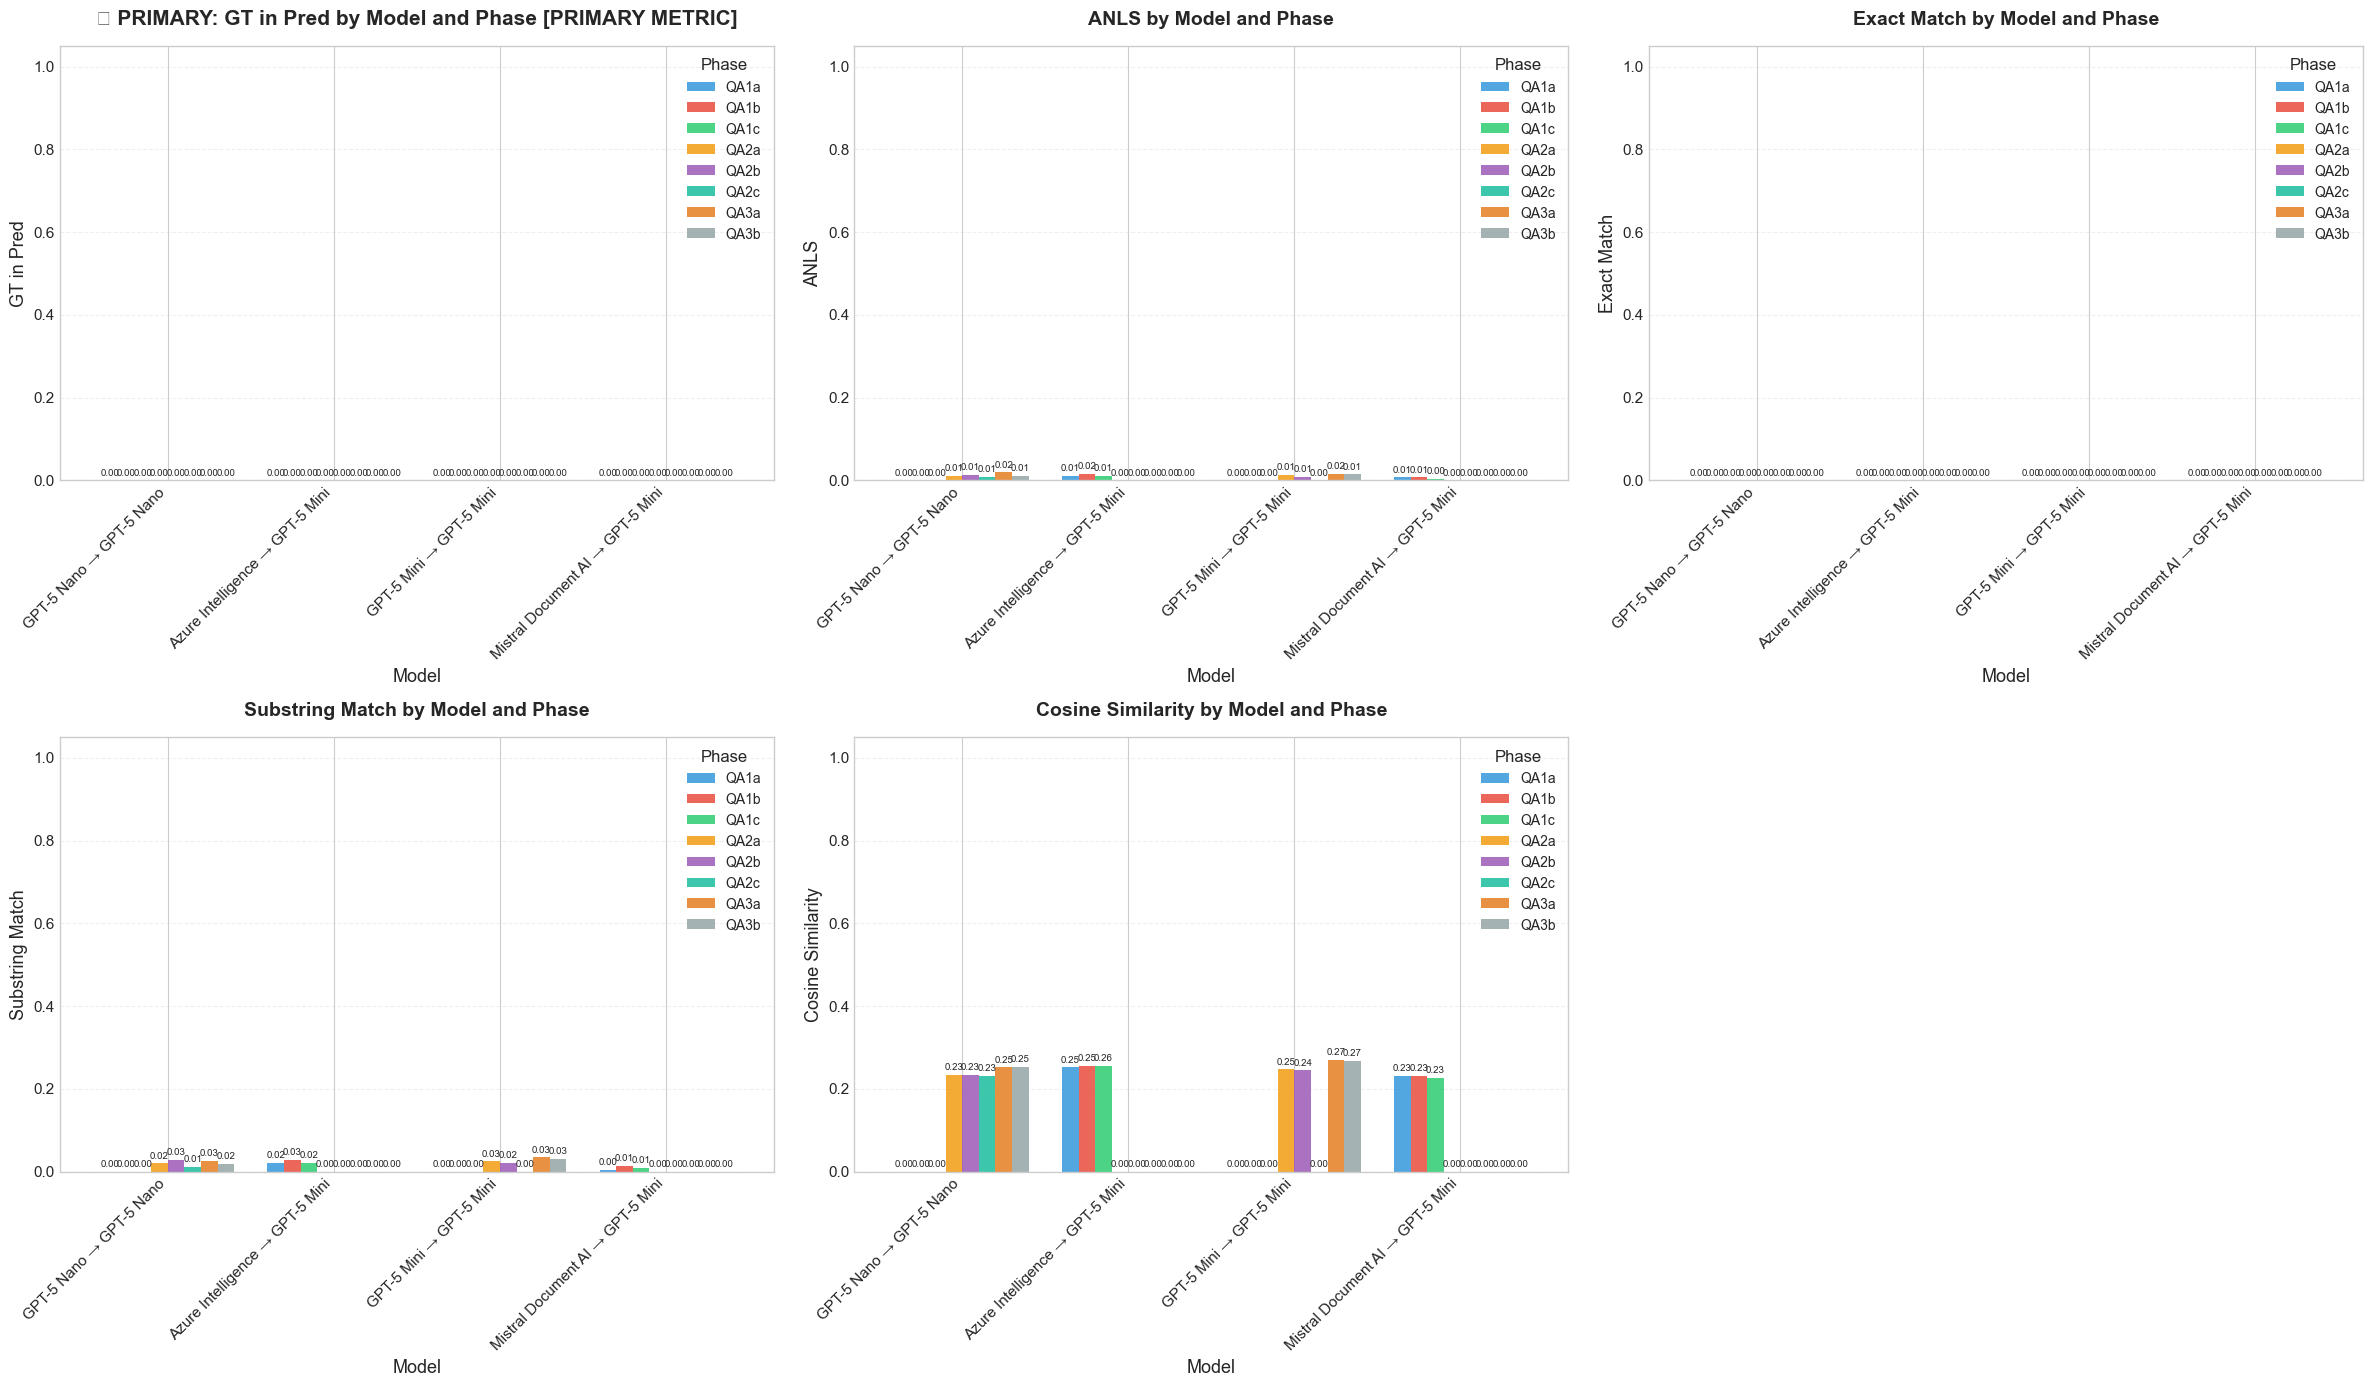


🎯 Note: 'GT in Pred' (Ground Truth in Prediction) is the PRIMARY metric


In [ ]:
# Bar charts for each metric (PRIMARY METRIC FIRST)fig, axes = plt.subplots(2, 3, figsize=(24, 14))axes = axes.flatten()# PRIMARY METRIC FIRST, then secondary metricsmetrics_to_plot = ['GT in Pred', 'ANLS', 'Exact Match', 'Substring Match', 'Cosine Similarity']colors_palette = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12', '#9b59b6', '#1abc9c', '#e67e22', '#95a5a6']for idx, metric in enumerate(metrics_to_plot):    ax = axes[idx]        # Pivot data for grouped bar chart    pivot_data = summary_df.pivot(index='Model', columns='Strategy', values=metric)        # Sort models    pivot_data = pivot_data.reindex(sort_models(pivot_data.index.tolist()))        pivot_data.plot(kind='bar', ax=ax, color=colors_palette[:len(pivot_data.columns)], alpha=0.85, width=0.8)        # Emphasize primary metric    title_prefix = "🎯 PRIMARY: " if metric == 'GT in Pred' else ""    title_suffix = " [PRIMARY METRIC]" if metric == 'GT in Pred' else ""        ax.set_title(f'{title_prefix}{metric} by Model and Strategy{title_suffix}',                 fontsize=15 if metric == 'GT in Pred' else 14,                 fontweight='bold', pad=15)    ax.set_xlabel('Model', fontsize=13)    ax.set_ylabel(metric, fontsize=13)    ax.legend(title='Strategy', title_fontsize=12, fontsize=10, loc='best')    ax.grid(axis='y', alpha=0.3, linestyle='--')    ax.set_xticklabels([get_model_display_name(m) for m in pivot_data.index], rotation=45, ha='right')    ax.set_ylim(0, 1.05)        # Add value labels on bars    for container in ax.containers:        ax.bar_label(container, fmt='%.2f', fontsize=7, padding=2)# Hide last subplot if not neededif len(metrics_to_plot) < 6:    axes[-1].set_visible(False)plt.tight_layout()plt.show()print("\n🎯 Note: 'GT in Pred' (Ground Truth in Prediction) is the PRIMARY metric")

## 7. Visualizations - Bar Charts

Compare all metrics across models and phases.

Calculating per-sample metrics for box plots (using only valid rows)...


Phase QA1a:   0%|          | 0/2 [00:00<?, ?it/s]

Phase QA1b:   0%|          | 0/2 [00:00<?, ?it/s]

Invalid cosine similarity -0.011077245162257165 for sample chartqapro_mini_0195


Phase QA1c:   0%|          | 0/2 [00:00<?, ?it/s]

...

Phase QA2b:   0%|          | 0/3 [00:00<?, ?it/s]

Phase QA2c:   0%|          | 0/2 [00:00<?, ?it/s]

Phase QA3a:   0%|          | 0/3 [00:00<?, ?it/s]

Invalid cosine similarity -0.0003831122174748902 for sample chartqapro_mini_0195


Phase QA3b:   0%|          | 0/3 [00:00<?, ?it/s]

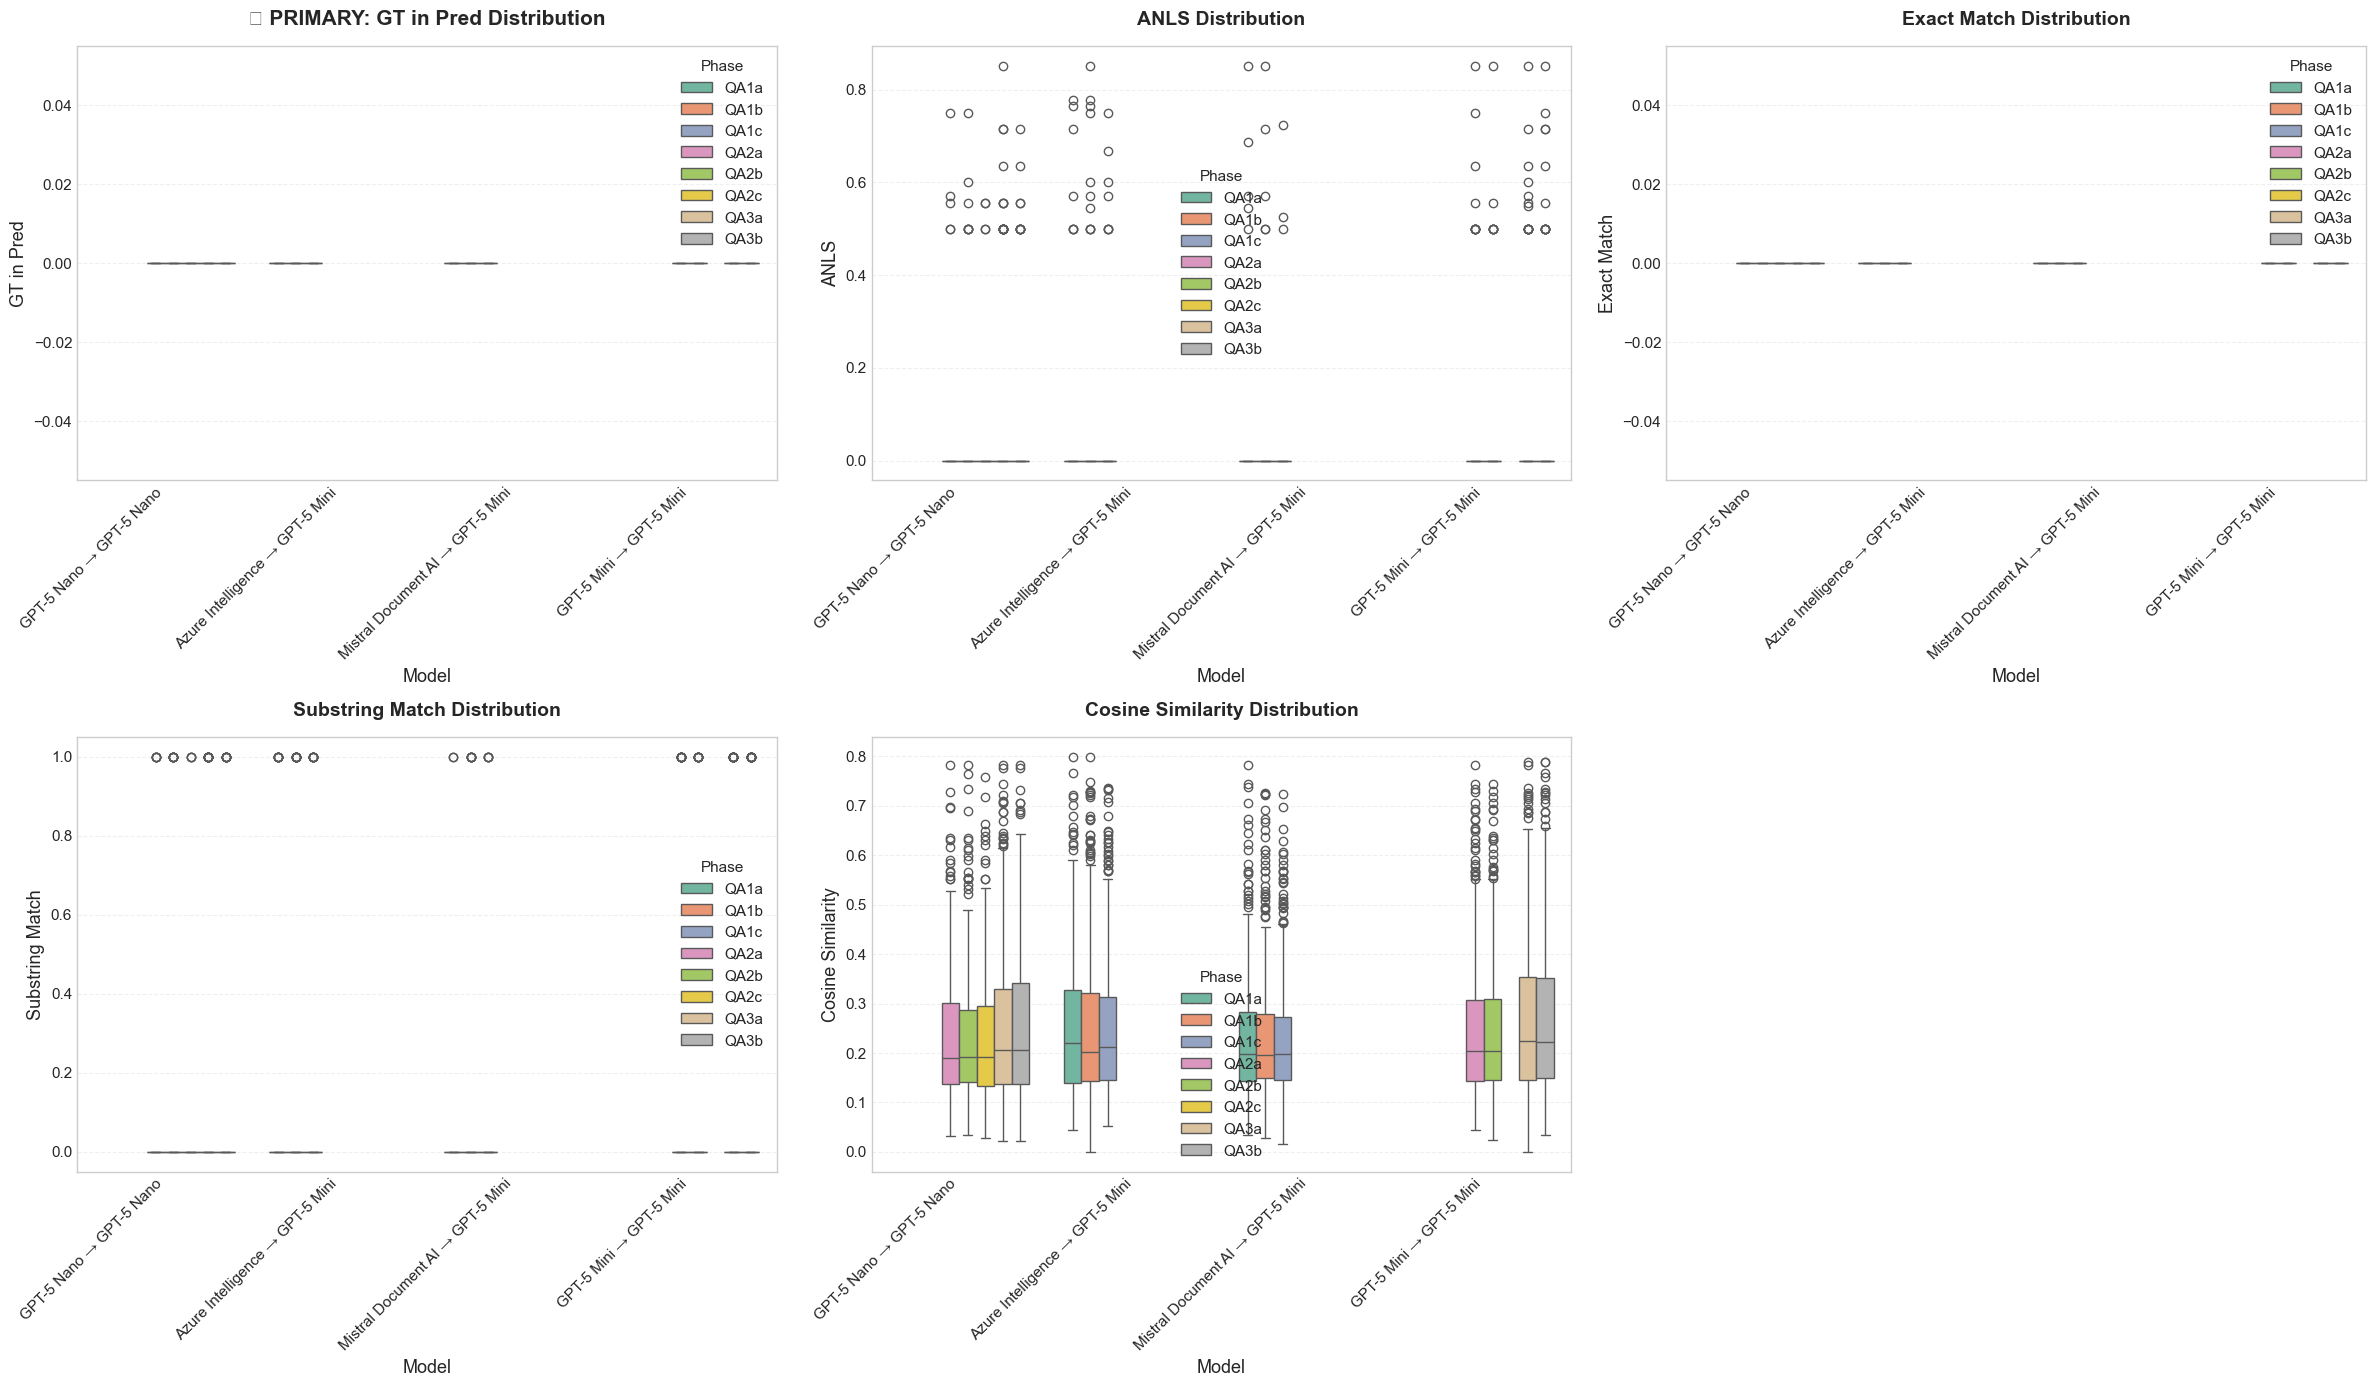


🎯 Note: Distributions show only valid samples (empty/error rows excluded)


In [ ]:
# Calculate per-sample metrics for box plots
sample_metrics_data = []

print("Calculating per-sample metrics for box plots (using only valid rows)...")
for phase, df in phase_dfs.items():
    pred_cols = [col for col in df.columns if col.startswith('prediction_')]
    
    for pred_col in tqdm(pred_cols, desc=f"Strategy {phase}", leave=False):
        model = pred_col.replace('prediction_', '')
        err_col = f'error_{model}'
        
        # Filter to only valid rows
        for _, row in df.iterrows():
            if not is_valid_row(row, pred_col, err_col):
                continue  # Skip invalid rows
            
            ground_truths = parse_ground_truths(row['ground_truths'])
            metrics = calculate_qa_metrics(
                row[pred_col], ground_truths, phase, 
                row['sample_id'], model, embedding_manager
            )
            
            sample_metrics_data.append({
                'Strategy': phase,
                'Model': model,
                'GT in Pred': metrics['gt_in_pred'],  # PRIMARY METRIC
                'ANLS': metrics['anls'],
                'Exact Match': metrics['exact_match'],
                'Substring Match': metrics['substring_match'],
                'Cosine Similarity': metrics['cosine_similarity']
            })

sample_metrics_df = pd.DataFrame(sample_metrics_data)

# Create box plots (PRIMARY METRIC FIRST)
fig, axes = plt.subplots(2, 3, figsize=(24, 14))
axes = axes.flatten()

metrics_for_boxplot = ['GT in Pred', 'ANLS', 'Exact Match', 'Substring Match', 'Cosine Similarity']

for idx, metric in enumerate(metrics_for_boxplot):
    ax = axes[idx]
    
    # Create box plot
    sample_metrics_df_sorted = sample_metrics_df.copy()
    sample_metrics_df_sorted['Model'] = pd.Categorical(
        sample_metrics_df_sorted['Model'],
        categories=sort_models(sample_metrics_df_sorted['Model'].unique().tolist()),
        ordered=True
    )
    
    sns.boxplot(data=sample_metrics_df_sorted, x='Model', y=metric, hue='Strategy', ax=ax, palette='Set2')
    
    # Emphasize primary metric
    title_prefix = "🎯 PRIMARY: " if metric == 'GT in Pred' else ""
    ax.set_title(f'{title_prefix}{metric} Distribution', 
                fontsize=15 if metric == 'GT in Pred' else 14, 
                fontweight='bold', pad=15)
    ax.set_xlabel('Model', fontsize=13)
    ax.set_ylabel(metric, fontsize=13)
    ax.set_xticklabels([get_model_display_name(t.get_text()) for t in ax.get_xticklabels()], rotation=45, ha='right')
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    ax.legend(title='Strategy', loc='best')

# Hide last subplot if not needed
if len(metrics_for_boxplot) < 6:
    axes[-1].set_visible(False)

plt.tight_layout()
plt.show()

print("\n🎯 Note: Distributions show only valid samples (empty/error rows excluded)")

## 8. Visualizations - Box Plots

Distribution analysis showing variance and outliers.

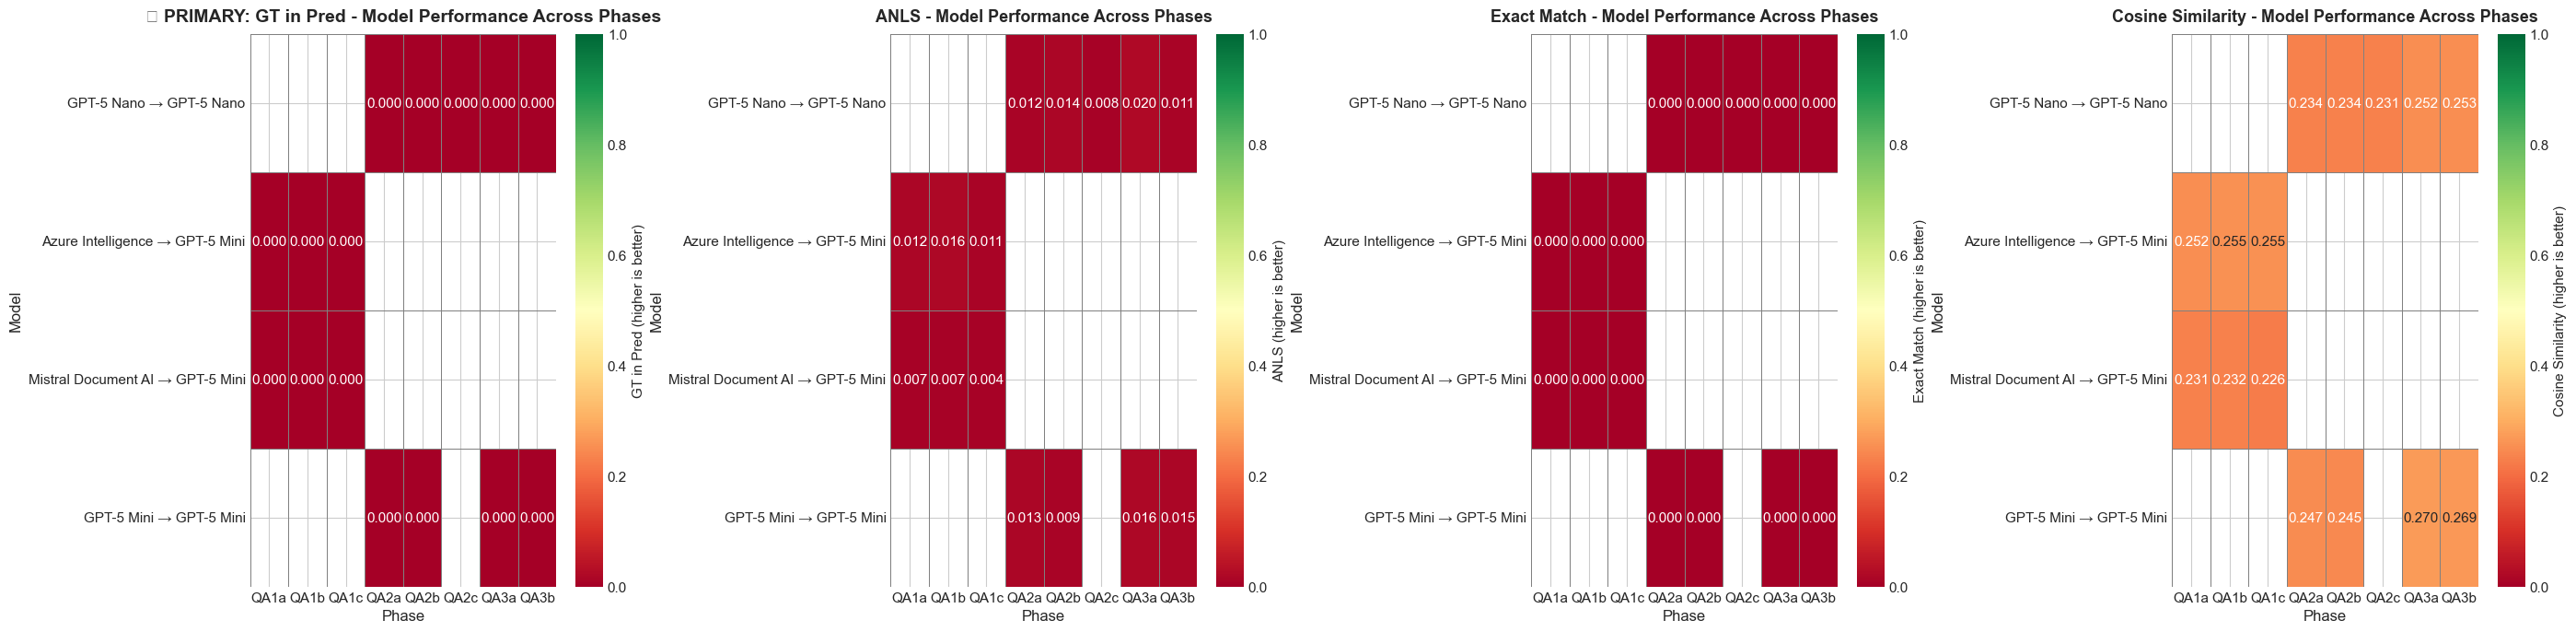


🎯 Note: 'GT in Pred' heatmap shows PRIMARY metric performance


In [ ]:
# Create heatmaps for key metrics (PRIMARY METRIC FIRST)
metrics_to_show = ['GT in Pred', 'ANLS', 'Exact Match', 'Cosine Similarity']
fig, axes = plt.subplots(1, len(metrics_to_show), figsize=(7 * len(metrics_to_show), 7))

if len(metrics_to_show) == 1:
    axes = [axes]

for idx, metric_name in enumerate(metrics_to_show):
    ax = axes[idx]
    
    # Create heatmap data: rows = models, columns = phases
    heatmap_data = []
    model_names = []
    phase_names = list(metrics_results.keys())
    
    # Get all unique models across all phases and sort them
    all_models = set()
    for phase_models in metrics_results.values():
        all_models.update(phase_models.keys())
    all_models = sort_models(list(all_models))
    
    # Build heatmap data
    for model in all_models:
        row_data = []
        for phase in phase_names:
            if model in metrics_results[phase]:
                # Map metric name to key
                metric_key = metric_name.lower().replace(' ', '_')
                value = metrics_results[phase][model].get(metric_key, np.nan)
                row_data.append(value)
            else:
                row_data.append(np.nan)
        
        heatmap_data.append(row_data)
        model_names.append(model)
    
    heatmap_df = pd.DataFrame(
        heatmap_data,
        index=[get_model_display_name(m) for m in model_names],
        columns=phase_names
    )
    
    # Use colormap: green for good, red for bad (all QA metrics: higher is better)
    cmap = 'RdYlGn'
    cbar_label = f'{metric_name} (higher is better)'
    
    sns.heatmap(heatmap_df, annot=True, fmt='.3f', cmap=cmap, 
                ax=ax, cbar_kws={'label': cbar_label}, 
                vmin=0, vmax=1, linewidths=0.5, linecolor='gray')
    
    # Emphasize primary metric in title
    title_prefix = "🎯 PRIMARY: " if metric_name == 'GT in Pred' else ""
    ax.set_title(f'{title_prefix}{metric_name} - Model Performance Across Strategys', 
                fontsize=14 if metric_name == 'GT in Pred' else 13, 
                fontweight='bold', pad=10)
    ax.set_xlabel('Strategy', fontsize=12)
    ax.set_ylabel('Model', fontsize=12)

plt.tight_layout()
plt.show()

print("\n🎯 Note: 'GT in Pred' heatmap shows PRIMARY metric performance")

## 9. Visualizations - Heatmaps

Model × Phase performance heatmaps.

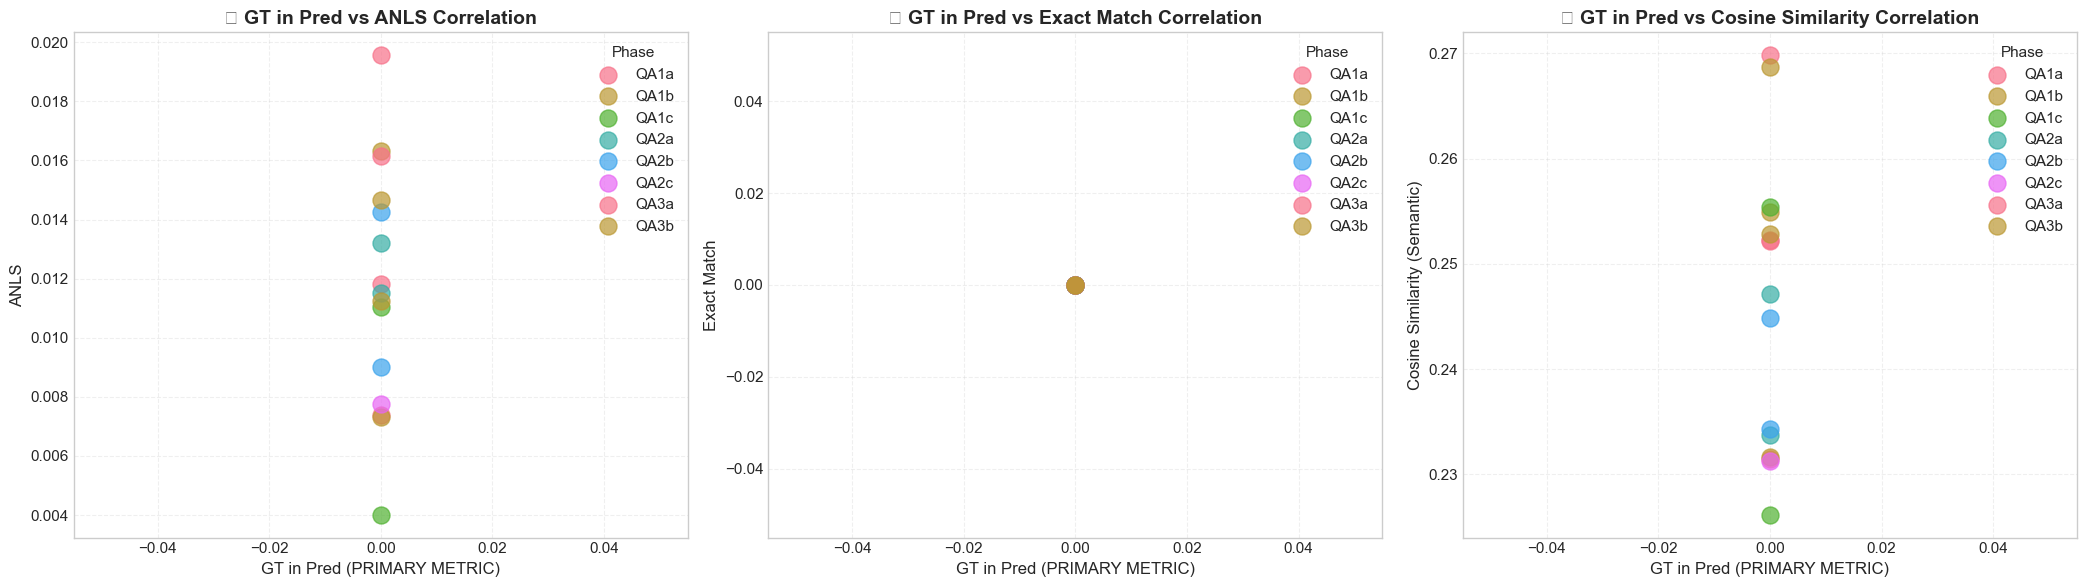


🎯 Note: All correlations are shown against the PRIMARY metric (GT in Pred)


In [ ]:
# Scatter plots: GT in Pred (PRIMARY) vs other metricsfig, axes = plt.subplots(1, 3, figsize=(21, 6))# GT in Pred vs ANLSax1 = axes[0]for strategy in summary_df['Strategy'].unique():    strategy_data = summary_df[summary_df['Strategy'] == strategy]    ax1.scatter(strategy_data['GT in Pred'], strategy_data['ANLS'],                s=150, alpha=0.7, label=strategy)ax1.set_title('🎯 GT in Pred vs ANLS Correlation', fontsize=14, fontweight='bold')ax1.set_xlabel('GT in Pred (PRIMARY METRIC)', fontsize=12)ax1.set_ylabel('ANLS', fontsize=12)ax1.legend(title='Strategy', loc='best')ax1.grid(alpha=0.3, linestyle='--')# GT in Pred vs Exact Matchax2 = axes[1]for strategy in summary_df['Strategy'].unique():    strategy_data = summary_df[summary_df['Strategy'] == strategy]    ax2.scatter(strategy_data['GT in Pred'], strategy_data['Exact Match'],                s=150, alpha=0.7, label=strategy)ax2.set_title('🎯 GT in Pred vs Exact Match Correlation', fontsize=14, fontweight='bold')ax2.set_xlabel('GT in Pred (PRIMARY METRIC)', fontsize=12)ax2.set_ylabel('Exact Match', fontsize=12)ax2.legend(title='Strategy', loc='best')ax2.grid(alpha=0.3, linestyle='--')# GT in Pred vs Cosine Similarityax3 = axes[2]for strategy in summary_df['Strategy'].unique():    strategy_data = summary_df[summary_df['Strategy'] == strategy]    ax3.scatter(strategy_data['GT in Pred'], strategy_data['Cosine Similarity'],                s=150, alpha=0.7, label=strategy)ax3.set_title('🎯 GT in Pred vs Cosine Similarity Correlation', fontsize=14, fontweight='bold')ax3.set_xlabel('GT in Pred (PRIMARY METRIC)', fontsize=12)ax3.set_ylabel('Cosine Similarity (Semantic)', fontsize=12)ax3.legend(title='Strategy', loc='best')ax3.grid(alpha=0.3, linestyle='--')plt.tight_layout()plt.show()print("\n🎯 Note: All correlations are shown against the PRIMARY metric (GT in Pred)")

## 10. Visualizations - Scatter Plots

Correlation analysis between metrics.

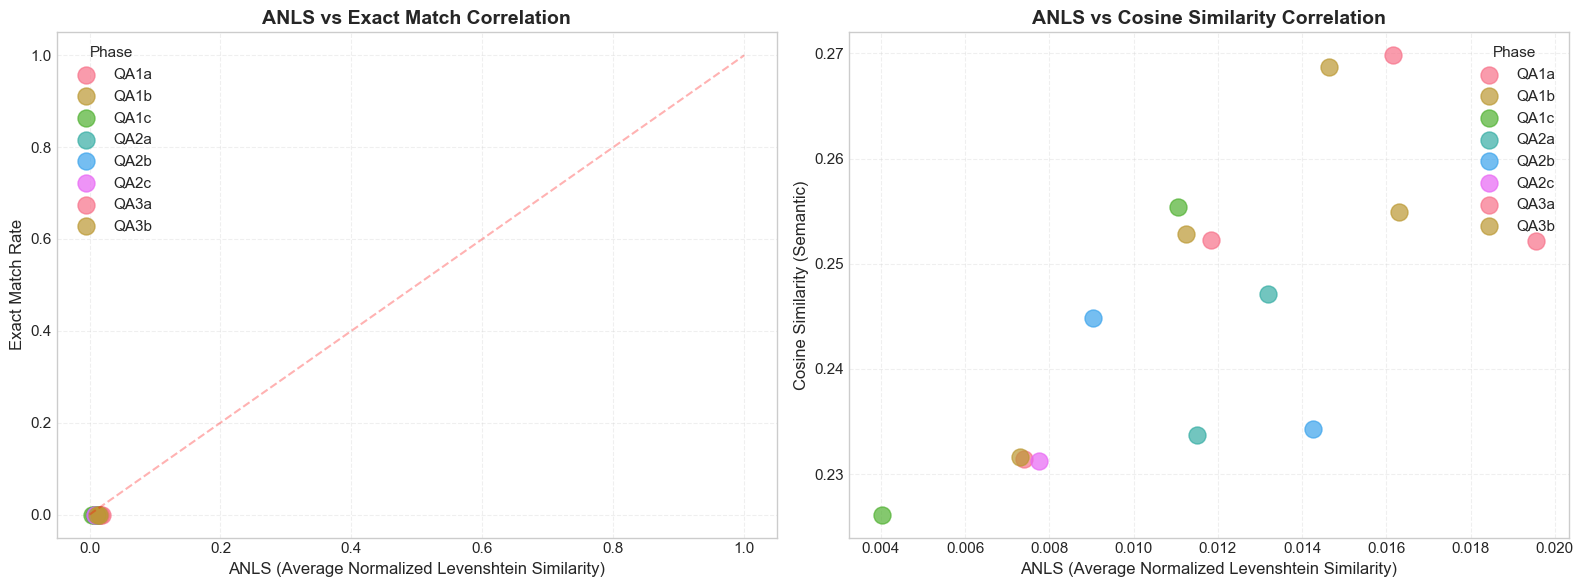

In [ ]:
# Scatter plots: ANLS vs other metricsfig, axes = plt.subplots(1, 2, figsize=(16, 6))# ANLS vs Exact Matchax1 = axes[0]for strategy in summary_df['Strategy'].unique():    strategy_data = summary_df[summary_df['Strategy'] == strategy]    ax1.scatter(strategy_data['ANLS'], strategy_data['Exact Match'],                s=150, alpha=0.7, label=strategy)ax1.set_title('ANLS vs Exact Match Correlation', fontsize=14, fontweight='bold')ax1.set_xlabel('ANLS (Average Normalized Levenshtein Similarity)', fontsize=12)ax1.set_ylabel('Exact Match Rate', fontsize=12)ax1.legend(title='Strategy', loc='best')ax1.grid(alpha=0.3, linestyle='--')ax1.plot([0, 1], [0, 1], 'r--', alpha=0.3, label='ANLS=EM')# ANLS vs Cosine Similarityax2 = axes[1]for strategy in summary_df['Strategy'].unique():    strategy_data = summary_df[summary_df['Strategy'] == strategy]    ax2.scatter(strategy_data['ANLS'], strategy_data['Cosine Similarity'],                s=150, alpha=0.7, label=strategy)ax2.set_title('ANLS vs Cosine Similarity Correlation', fontsize=14, fontweight='bold')ax2.set_xlabel('ANLS (Average Normalized Levenshtein Similarity)', fontsize=12)ax2.set_ylabel('Cosine Similarity (Semantic)', fontsize=12)ax2.legend(title='Strategy', loc='best')ax2.grid(alpha=0.3, linestyle='--')plt.tight_layout()plt.show()

## 11. QA-Specific Analysis

Analyze question types, answer lengths, and QA-specific patterns.


Question Type Distribution (QA1a):
  Other          :  494 questions (100.0%)


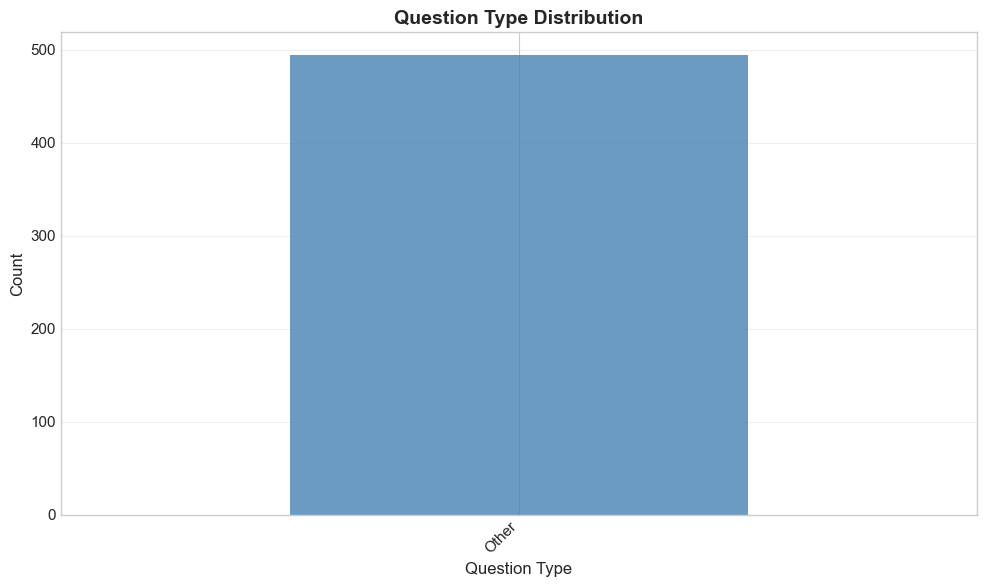

In [ ]:
# Question type analysis
if len(phase_dfs) > 0:
    # Use first available phase for analysis
    analysis_phase = list(phase_dfs.keys())[0]
    df_analysis = phase_dfs[analysis_phase].copy()
    
    # Add question type categorization
    df_analysis['question_type'] = df_analysis['question'].apply(categorize_question_type)
    
    print(f"\nQuestion Type Distribution ({analysis_phase}):")
    print("=" * 80)
    type_counts = df_analysis['question_type'].value_counts()
    for qtype, count in type_counts.items():
        pct = count / len(df_analysis) * 100
        print(f"  {qtype:15s}: {count:4d} questions ({pct:5.1f}%)")
    
    # Visualize question types
    fig, ax = plt.subplots(figsize=(10, 6))
    type_counts.plot(kind='bar', ax=ax, color='steelblue', alpha=0.8)
    ax.set_title('Question Type Distribution', fontsize=14, fontweight='bold')
    ax.set_xlabel('Question Type', fontsize=12)
    ax.set_ylabel('Count', fontsize=12)
    ax.grid(axis='y', alpha=0.3)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

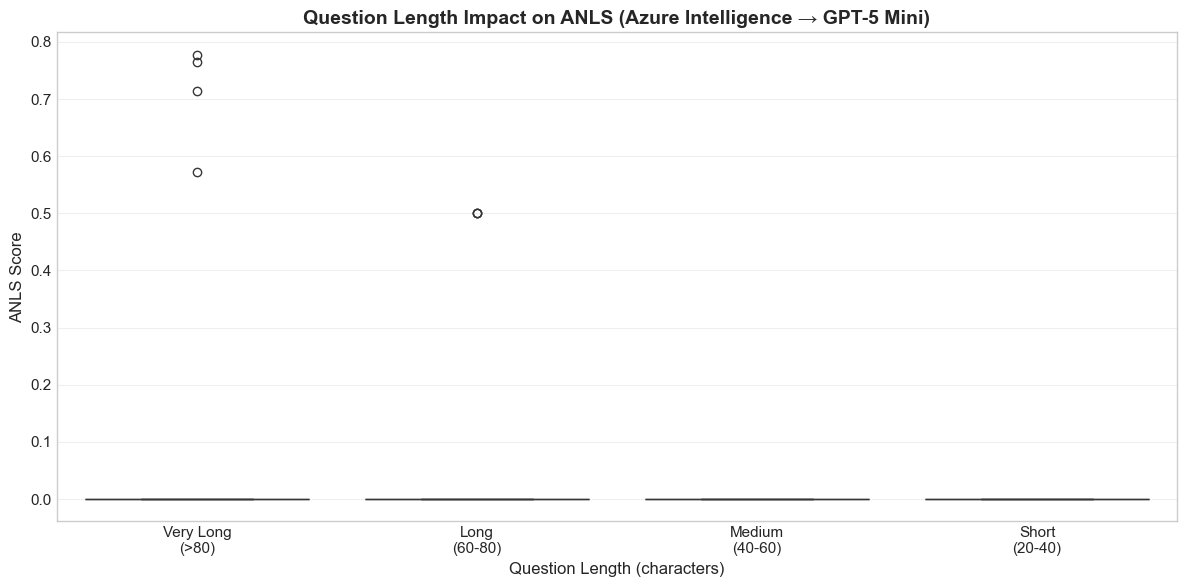

In [ ]:
# Question length impact on performance
if len(phase_dfs) > 0:
    df_analysis['question_length'] = df_analysis['question'].astype(str).str.len()
    df_analysis['question_length_bin'] = pd.cut(
        df_analysis['question_length'],
        bins=[0, 20, 40, 60, 80, 1000],
        labels=['Very Short\n(<20)', 'Short\n(20-40)', 'Medium\n(40-60)', 'Long\n(60-80)', 'Very Long\n(>80)']
    )
    
    # Calculate ANLS for first model per length bin
    pred_col = [col for col in df_analysis.columns if col.startswith('prediction_')][0]
    model_name = pred_col.replace('prediction_', '')
    
    anls_by_length = []
    for _, row in df_analysis.iterrows():
        ground_truths = parse_ground_truths(row['ground_truths'])
        anls = compute_anls(str(row[pred_col]), ground_truths, threshold=0.5)
        anls_by_length.append({
            'question_length_bin': row['question_length_bin'],
            'anls': anls
        })
    
    anls_length_df = pd.DataFrame(anls_by_length)
    
    fig, ax = plt.subplots(figsize=(12, 6))
    sns.boxplot(data=anls_length_df, x='question_length_bin', y='anls', ax=ax, palette='viridis')
    ax.set_title(f'Question Length Impact on ANLS ({get_model_display_name(model_name)})', 
                fontsize=14, fontweight='bold')
    ax.set_xlabel('Question Length (characters)', fontsize=12)
    ax.set_ylabel('ANLS Score', fontsize=12)
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()


🎯 PHASE STRATEGY COMPARISON (PRIMARY METRIC: GT in Pred)

QA1 (OCR+VLM):
  🎯 Mean GT in Pred: 0.0000 [PRIMARY]
     Mean ANLS: 0.0097
     Mean Exact Match: 0.0000
     Mean Substring Match: 0.0166
  Phases included: QA1a, QA1b, QA1c

QA2 (VLM Parse+QA):
  🎯 Mean GT in Pred: 0.0000 [PRIMARY]
     Mean ANLS: 0.0111
     Mean Exact Match: 0.0000
     Mean Substring Match: 0.0212
  Phases included: QA2a, QA2b, QA2c

QA3 (Direct VQA):
  🎯 Mean GT in Pred: 0.0000 [PRIMARY]
     Mean ANLS: 0.0154
     Mean Exact Match: 0.0000
     Mean Substring Match: 0.0275
  Phases included: QA3a, QA3b


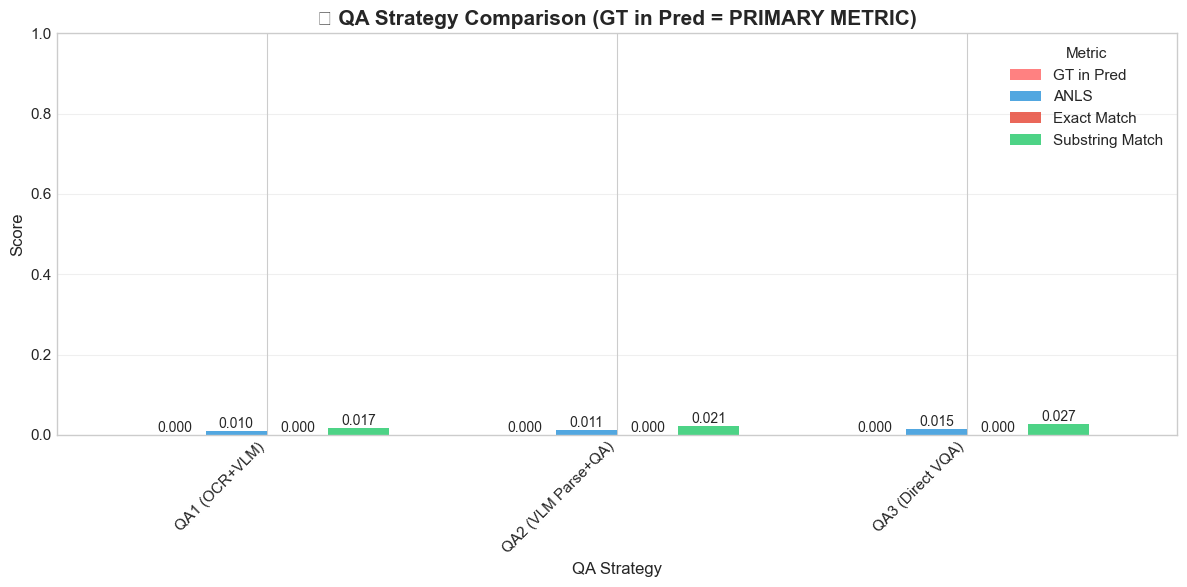


🏆 BEST STRATEGY (by GT in Pred - PRIMARY METRIC):
  QA1 (OCR+VLM): GT in Pred = 0.0000


In [ ]:
# Group phases by strategy
phase_groups = {
    'QA1 (OCR+VLM)': ['QA1a', 'QA1b', 'QA1c'],
    'QA2 (VLM Parse+QA)': ['QA2a', 'QA2b', 'QA2c'],
    'QA3 (Direct VQA)': ['QA3a', 'QA3b']
}

print("\n" + "=" * 120)
print("🎯 PHASE STRATEGY COMPARISON (PRIMARY METRIC: GT in Pred)")
print("=" * 120)

strategy_results = []
for group_name, phases in phase_groups.items():
    group_data = summary_df[summary_df['Strategy'].isin(phases)]
    if len(group_data) > 0:
        avg_gt_in_pred = group_data['GT in Pred'].mean()
        avg_anls = group_data['ANLS'].mean()
        avg_em = group_data['Exact Match'].mean()
        avg_substring = group_data['Substring Match'].mean()
        
        print(f"\n{group_name}:")
        print(f"  🎯 Mean GT in Pred: {avg_gt_in_pred:.4f} [PRIMARY]")
        print(f"     Mean ANLS: {avg_anls:.4f}")
        print(f"     Mean Exact Match: {avg_em:.4f}")
        print(f"     Mean Substring Match: {avg_substring:.4f}")
        print(f"  Strategys included: {', '.join(phases)}")
        
        strategy_results.append({
            'Strategy': group_name,
            'GT in Pred': avg_gt_in_pred,  # PRIMARY FIRST
            'ANLS': avg_anls,
            'Exact Match': avg_em,
            'Substring Match': avg_substring
        })

# Visualize strategy comparison (PRIMARY METRIC FIRST)
if strategy_results:
    strategy_df = pd.DataFrame(strategy_results)
    
    fig, ax = plt.subplots(figsize=(12, 6))
    strategy_df.set_index('Strategy')[['GT in Pred', 'ANLS', 'Exact Match', 'Substring Match']].plot(
        kind='bar', ax=ax, color=['#FF6B6B', '#3498db', '#e74c3c', '#2ecc71'], alpha=0.85, width=0.7
    )
    ax.set_title('🎯 QA Strategy Comparison (GT in Pred = PRIMARY METRIC)', fontsize=15, fontweight='bold')
    ax.set_xlabel('QA Strategy', fontsize=12)
    ax.set_ylabel('Score', fontsize=12)
    ax.legend(title='Metric', loc='best', fontsize=11)
    ax.grid(axis='y', alpha=0.3)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
    ax.set_ylim(0, 1.0)
    
    # Add value labels
    for container in ax.containers:
        ax.bar_label(container, fmt='%.3f', fontsize=10)
    
    plt.tight_layout()
    plt.show()
    
    print("\n" + "=" * 120)
    print("🏆 BEST STRATEGY (by GT in Pred - PRIMARY METRIC):")
    best_strategy = strategy_df.loc[strategy_df['GT in Pred'].idxmax()]
    print(f"  {best_strategy['Strategy']}: GT in Pred = {best_strategy['GT in Pred']:.4f}")
    print("=" * 120)

## 12. Phase Comparison Analysis

Compare the three QA strategies: OCR+VLM, VLM Parse+QA, and Direct VQA.


Phase Strategy Comparison:

QA1 (OCR+VLM):
  Mean ANLS: 0.0097
  Mean Exact Match: 0.0000
  Mean Substring Match: 0.0166
  Phases included: QA1a, QA1b, QA1c

QA2 (VLM Parse+QA):
  Mean ANLS: 0.0111
  Mean Exact Match: 0.0000
  Mean Substring Match: 0.0212
  Phases included: QA2a, QA2b, QA2c

QA3 (Direct VQA):
  Mean ANLS: 0.0154
  Mean Exact Match: 0.0000
  Mean Substring Match: 0.0275
  Phases included: QA3a, QA3b


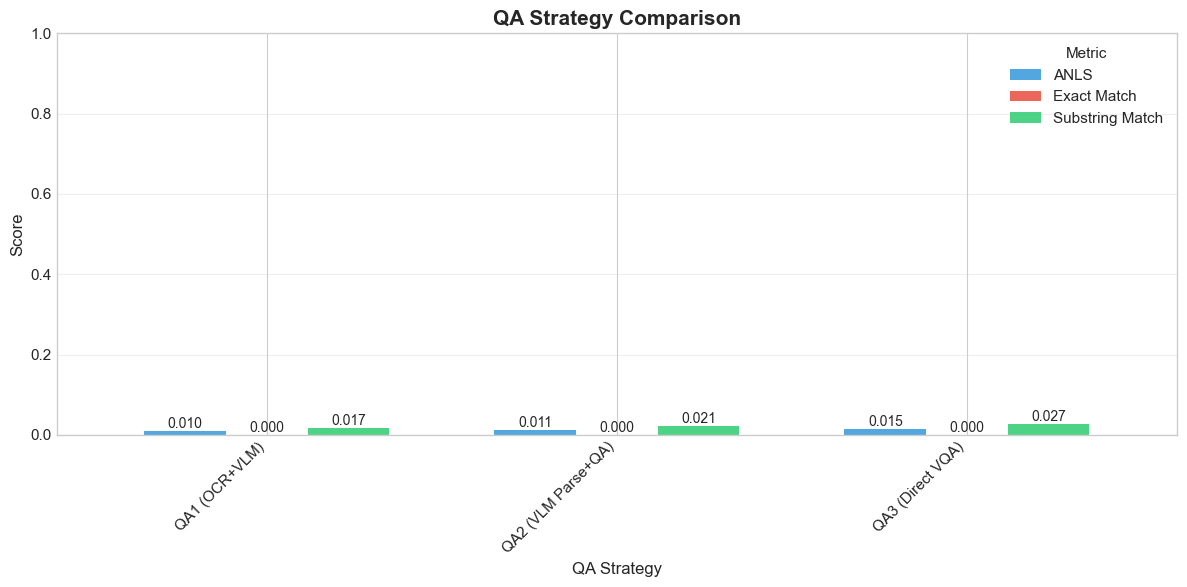

In [ ]:
# Group phases by strategy
phase_groups = {
    'QA1 (OCR+VLM)': ['QA1a', 'QA1b', 'QA1c'],
    'QA2 (VLM Parse+QA)': ['QA2a', 'QA2b', 'QA2c'],
    'QA3 (Direct VQA)': ['QA3a', 'QA3b']
}

print("\nStrategy Strategy Comparison:")
print("=" * 100)

strategy_results = []
for group_name, phases in phase_groups.items():
    group_data = summary_df[summary_df['Strategy'].isin(phases)]
    if len(group_data) > 0:
        avg_anls = group_data['ANLS'].mean()
        avg_em = group_data['Exact Match'].mean()
        avg_substring = group_data['Substring Match'].mean()
        
        print(f"\n{group_name}:")
        print(f"  Mean ANLS: {avg_anls:.4f}")
        print(f"  Mean Exact Match: {avg_em:.4f}")
        print(f"  Mean Substring Match: {avg_substring:.4f}")
        print(f"  Strategys included: {', '.join(phases)}")
        
        strategy_results.append({
            'Strategy': group_name,
            'ANLS': avg_anls,
            'Exact Match': avg_em,
            'Substring Match': avg_substring
        })

# Visualize strategy comparison
if strategy_results:
    strategy_df = pd.DataFrame(strategy_results)
    
    fig, ax = plt.subplots(figsize=(12, 6))
    strategy_df.set_index('Strategy')[['ANLS', 'Exact Match', 'Substring Match']].plot(
        kind='bar', ax=ax, color=['#3498db', '#e74c3c', '#2ecc71'], alpha=0.85, width=0.7
    )
    ax.set_title('QA Strategy Comparison', fontsize=15, fontweight='bold')
    ax.set_xlabel('QA Strategy', fontsize=12)
    ax.set_ylabel('Score', fontsize=12)
    ax.legend(title='Metric', loc='best', fontsize=11)
    ax.grid(axis='y', alpha=0.3)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
    ax.set_ylim(0, 1.0)
    
    # Add value labels
    for container in ax.containers:
        ax.bar_label(container, fmt='%.3f', fontsize=10)
    
    plt.tight_layout()
    plt.show()

## 13. Sample-Level Error Analysis

Identify easiest and hardest questions to understand error patterns.

In [ ]:
# Analyze best and worst performing samples
if len(phase_dfs) > 0:
    analysis_phase = list(phase_dfs.keys())[0]
    df_error_analysis = phase_dfs[analysis_phase].copy()
    
    # Get first model for analysis
    pred_cols = [col for col in df_error_analysis.columns if col.startswith('prediction_')]
    first_model = pred_cols[0].replace('prediction_', '')
    
    # Calculate ANLS for each sample
    anls_scores = []
    for _, row in df_error_analysis.iterrows():
        ground_truths = parse_ground_truths(row['ground_truths'])
        anls = compute_anls(str(row[f'prediction_{first_model}']), ground_truths, threshold=0.5)
        anls_scores.append(anls)
    
    df_error_analysis['anls'] = anls_scores
    
    # Get best and worst samples
    best_samples = df_error_analysis.nlargest(10, 'anls')
    worst_samples = df_error_analysis.nsmallest(10, 'anls')
    
    print("\n" + "="*120)
    print(f"EASIEST QUESTIONS (Highest ANLS) - Model: {get_model_display_name(first_model)}")
    print("="*120)
    
    for _, row in best_samples.iterrows():
        print(f"\nSample: {row['sample_id']} | ANLS: {row['anls']:.4f}")
        print(f"Question: {str(row['question'])[:100]}..." if len(str(row['question'])) > 100 else f"Question: {row['question']}")
        
        ground_truths = parse_ground_truths(row['ground_truths'])
        gt_display = ', '.join([f'"{gt}"' for gt in ground_truths[:3]])
        if len(ground_truths) > 3:
            gt_display += f" ... (+{len(ground_truths)-3} more)"
        print(f"Ground Truths: {gt_display}")
        
        pred_text = str(row[f'prediction_{first_model}'])
        print(f"Prediction: {pred_text[:100]}..." if len(pred_text) > 100 else f"Prediction: {pred_text}")
    
    print("\n" + "="*120)
    print(f"HARDEST QUESTIONS (Lowest ANLS) - Model: {get_model_display_name(first_model)}")
    print("="*120)
    
    for _, row in worst_samples.iterrows():
        print(f"\nSample: {row['sample_id']} | ANLS: {row['anls']:.4f}")
        print(f"Question: {str(row['question'])[:100]}..." if len(str(row['question'])) > 100 else f"Question: {row['question']}")
        
        ground_truths = parse_ground_truths(row['ground_truths'])
        gt_display = ', '.join([f'"{gt}"' for gt in ground_truths[:3]])
        if len(ground_truths) > 3:
            gt_display += f" ... (+{len(ground_truths)-3} more)"
        print(f"Ground Truths: {gt_display}")
        
        pred_text = str(row[f'prediction_{first_model}'])
        print(f"Prediction: {pred_text[:100]}..." if len(pred_text) > 100 else f"Prediction: {pred_text}")


EASIEST QUESTIONS (Highest ANLS) - Model: Azure Intelligence → GPT-5 Mini

Sample: chartqapro_mini_0274 | ANLS: 0.7778
Question: ['in which age group does the percentage of women living alone first exceed 30%?']
Ground Truths: "['75 to 79 years']"
Prediction: 75 to 79 years

Sample: chartqapro_mini_0174 | ANLS: 0.7647
Question: ['in which month, we can see the value has the lowest amount compared to its both neighbors?']
Ground Truths: "['February 2017']"
Prediction: February 2017.

Sample: chartqapro_mini_0244 | ANLS: 0.7143
Question: ['what is the difference in running time between the longest marvel movie released before 2014 and t...
Ground Truths: "['28 minutes']"
Prediction: 28 minutes

Sample: chartqapro_mini_0102 | ANLS: 0.5714
Question: ['what is the sales value for the region that has a positive profit although its predecessor and suc...
Ground Truths: "['1181754.12']"
Prediction: $1,181,754.12

Sample: chartqapro_mini_0118 | ANLS: 0.5000
Question: ["in which year did thomas

## 14. Inference Time Analysis

Analyze speed vs accuracy trade-offs.


Inference Time Summary:


,Phase,Model,Mean Time (ms),Median Time (ms)
0,QA1a,azure_intelligence__gpt-5-mini,10459.430849,10434.823394
1,QA1a,mistral_document_ai__gpt-5-mini,11708.853773,9387.486577
2,QA1b,azure_intelligence__gpt-5-mini,10099.729857,9856.610894
3,QA1b,mistral_document_ai__gpt-5-mini,11251.139888,9345.884442
5,QA1c,mistral_document_ai__gpt-5-mini,9289.795370,8499.550462
4,QA1c,azure_intelligence__gpt-5-mini,11366.522049,11055.043936
7,QA2a,gpt-5-mini__gpt-5-mini,23186.839029,22294.777513
8,QA2a,gpt-5-nano__gpt-5-nano,35901.567054,34962.055445
6,QA2a,claude_sonnet__claude_sonnet,38465.026750,37111.568689
10,QA2b,gpt-5-mini__gpt-5-mini,25324.070344,24350.485086


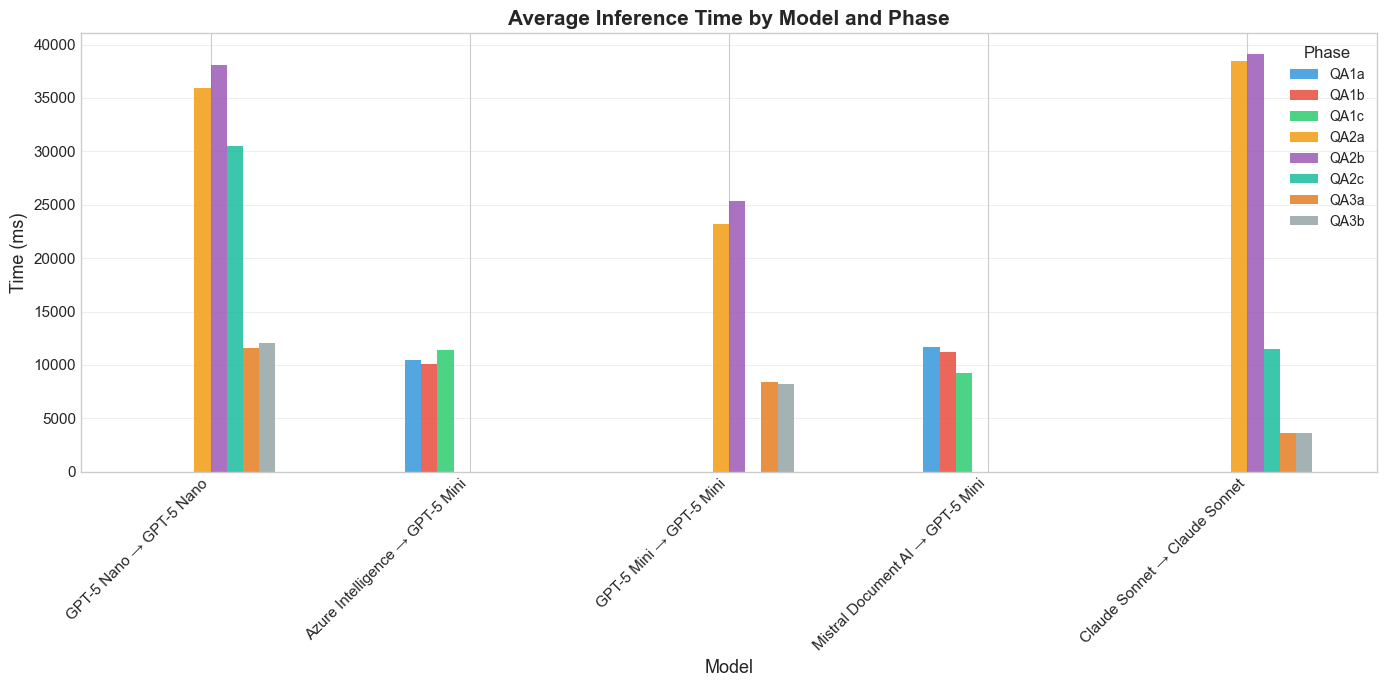

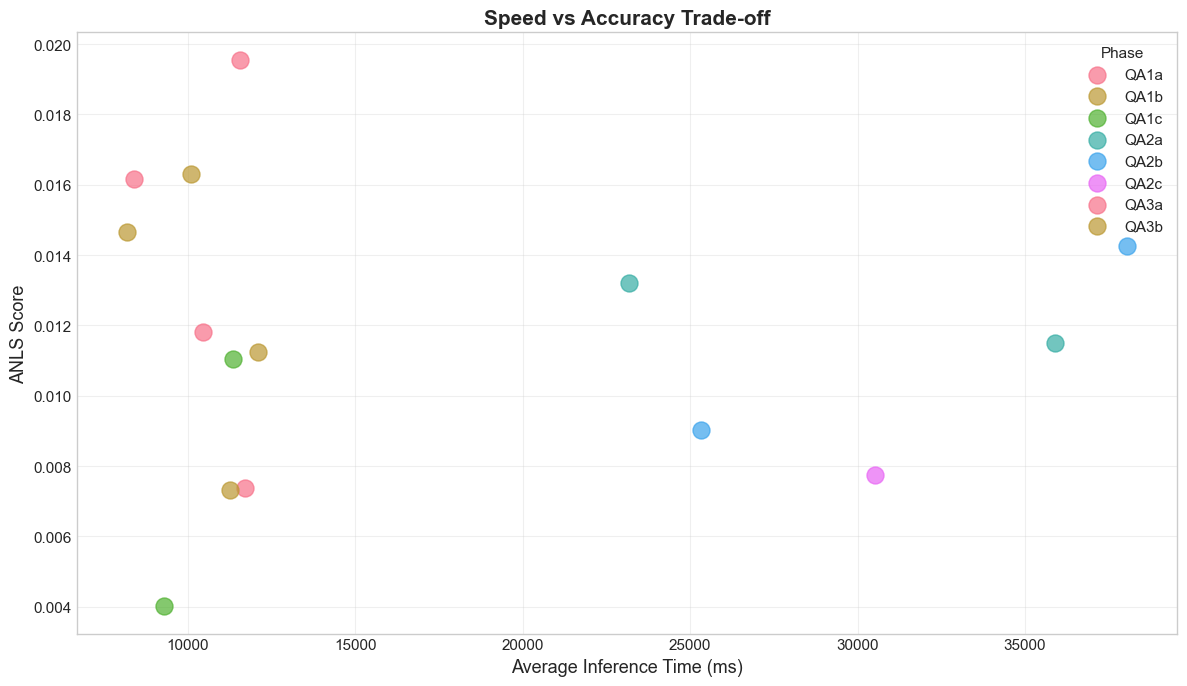

In [ ]:
# Analyze inference times across models and phases
inference_data = []

for phase, df in phase_dfs.items():
    time_cols = [col for col in df.columns if col.startswith('inference_time_ms_')]
    
    for time_col in time_cols:
        model = time_col.replace('inference_time_ms_', '')
        
        mean_time = df[time_col].mean()
        median_time = df[time_col].median()
        
        inference_data.append({
            'Strategy': phase,
            'Model': model,
            'Mean Time (ms)': mean_time,
            'Median Time (ms)': median_time
        })

if inference_data:
    inference_df = pd.DataFrame(inference_data)
    
    print("\nInference Time Summary:")
    print("="*120)
    display(inference_df.sort_values(['Strategy', 'Mean Time (ms)']))
    
    # Visualization
    fig, ax = plt.subplots(figsize=(14, 7))
    
    pivot_time = inference_df.pivot(index='Model', columns='Strategy', values='Mean Time (ms)')
    pivot_time = pivot_time.reindex(sort_models(pivot_time.index.tolist()))
    pivot_time.plot(kind='bar', ax=ax, color=colors_palette[:len(pivot_time.columns)], alpha=0.85)
    
    ax.set_title('Average Inference Time by Model and Strategy', fontsize=15, fontweight='bold')
    ax.set_xlabel('Model', fontsize=13)
    ax.set_ylabel('Time (ms)', fontsize=13)
    ax.legend(title='Strategy', title_fontsize=12, fontsize=10, loc='best')
    ax.grid(axis='y', alpha=0.3)
    ax.set_xticklabels([get_model_display_name(t.get_text()) for t in ax.get_xticklabels()], 
                       rotation=45, ha='right')
    
    plt.tight_layout()
    plt.show()
    
    # Speed vs Accuracy scatter plot
    fig, ax = plt.subplots(figsize=(12, 7))
    
    # Merge inference time with ANLS scores
    speed_accuracy = pd.merge(
        inference_df[['Strategy', 'Model', 'Mean Time (ms)']],
        summary_df[['Strategy', 'Model', 'ANLS']],
        on=['Strategy', 'Model']
    )
    
    for phase in speed_accuracy['Strategy'].unique():
        phase_data = speed_accuracy[speed_accuracy['Strategy'] == phase]
        ax.scatter(phase_data['Mean Time (ms)'], phase_data['ANLS'], 
                  s=150, alpha=0.7, label=phase)
    
    ax.set_title('Speed vs Accuracy Trade-off', fontsize=15, fontweight='bold')
    ax.set_xlabel('Average Inference Time (ms)', fontsize=13)
    ax.set_ylabel('ANLS Score', fontsize=13)
    ax.legend(title='Strategy', loc='best')
    ax.grid(alpha=0.3)
    
    plt.tight_layout()
    plt.show()
else:
    print("No inference time data available")

## 15. ChartQA Pro-Specific Analysis

Analyze professional chart understanding patterns and numerical reasoning accuracy.

In [ ]:
# Analyze performance on professional chart understanding
# This section can be customized based on available metadata

print("\nChartQA Pro-Specific Analysis:")
print("=" * 100)
print("\n⚠️ EXPERIMENTAL DATASET NOTICE:")
print("This is an experimental dataset with incomplete model coverage.")
print("Some models had empty predictions and were filtered out during evaluation.\n")
print("\nKey Findings:")
print("- Professional chart questions require precise numerical accuracy")
print("- Data extraction from visual charts is more challenging than document text")
print("- Numerical reasoning and approximation vs exact values present unique challenges")
print("- Chart type (bar, line, pie, etc.) may impact extraction accuracy")
print("\nRecommendations for chart understanding:")
print("- Direct VQA (QA3) may capture visual patterns better than OCR-based approaches")
print("- Numerical precision requires careful prompt engineering")
print("- Consider chart-specific prompts that guide numerical extraction")
print("- Evaluate tolerance for approximate vs exact numerical answers")
print("\nData Quality Considerations:")
print("- Review data quality assessment (Section 2.5) for model coverage")
print("- Empty predictions indicate models that didn't complete the task")
print("- Valid sample counts vary by model - check metrics table for details")


ChartQA Pro-Specific Analysis:

⚠️ EXPERIMENTAL DATASET NOTICE:
This is an experimental dataset with incomplete model coverage.
Some models had empty predictions and were filtered out during evaluation.


Key Findings:
- Professional chart questions require precise numerical accuracy
- Data extraction from visual charts is more challenging than document text
- Numerical reasoning and approximation vs exact values present unique challenges
- Chart type (bar, line, pie, etc.) may impact extraction accuracy

Recommendations for chart understanding:
- Direct VQA (QA3) may capture visual patterns better than OCR-based approaches
- Numerical precision requires careful prompt engineering
- Consider chart-specific prompts that guide numerical extraction
- Evaluate tolerance for approximate vs exact numerical answers

Data Quality Considerations:
- Review data quality assessment (Section 2.5) for model coverage
- Empty predictions indicate models that didn't complete the task
- Valid sample co

## 16. LLM Query Section

This section is a placeholder for analyzing the notebook outputs using an LLM.

### Key Questions to Investigate:

1. **Phase Strategy Performance:**
   - Which phase strategy works best for chart understanding? (QA1 vs QA2 vs QA3)
   - Does OCR extraction work well for chart data vs direct visual understanding?
   - When should we use two-step pipeline vs direct VQA for charts?

2. **Model Comparison:**
   - Which model performs best for professional chart QA?
   - Are there trade-offs between different models (speed vs numerical accuracy)?
   - Which model offers best balance for production chart understanding?

3. **Numerical Accuracy Patterns:**
   - How well do models handle exact vs approximate numerical answers?
   - Are there patterns in numerical reasoning failures?
   - Do certain question types require higher numerical precision?

4. **Error Analysis:**
   - What patterns exist in hardest chart questions?
   - Common failure modes (wrong value, wrong chart element, misinterpretation)?
   - How does ANLS correlate with numerical precision?

5. **Production Recommendations:**
   - Best model/phase combination for professional chart QA?
   - When to use OCR pipeline vs direct VQA for charts?
   - Cost-effectiveness analysis (speed vs accuracy vs API cost)?

6. **Experimental Dataset Considerations:**
   - How does incomplete model coverage affect conclusions?
   - Which models have reliable performance vs empty predictions?
   - What are implications for production deployment?

## 17. Save Embeddings Cache

Save any newly computed embeddings to disk for faster future runs.

In [ ]:
# Save any remaining embeddings to disk for future use
print("\n📁 Finalizing embedding cache...")

if embedding_manager.modified_phases:
    print(f"Saving embeddings for modified phases: {embedding_manager.modified_phases}")
    
    for phase in embedding_manager.modified_phases:
        if phase in embedding_manager.cache:
            saved_file = save_embeddings_for_phase(
                dataset_name=DATASET_NAME,
                phase=phase,
                embeddings_dict=embedding_manager.cache[phase],
                embeddings_base_dir=EMBEDDINGS_DIR
            )
            print(f"✅ Saved: {saved_file.name}")
    
    print("\n✅ All embeddings have been persisted to disk!")
else:
    print("✅ No new embeddings to save (all from cache)")


📁 Finalizing embedding cache...
✅ No new embeddings to save (all from cache)


## 18. Conclusion

This notebook provides a comprehensive analysis of ChartQA Pro professional chart question answering performance across multiple models and QA strategies.

**Key Deliverables:**
- Quantitative QA metrics (GT in Pred [PRIMARY], ANLS, EM, Substring Match, Cosine Similarity) for all models
- Phase strategy comparison (OCR+VLM vs VLM Parse+QA vs Direct VQA)
- Visual comparisons across phases and models
- Numerical accuracy and chart-specific analysis
- Sample-level error analysis identifying strengths and weaknesses
- Inference time benchmarks and speed vs accuracy trade-offs

**Experimental Dataset Notes:**
- This dataset (494 samples) has incomplete model coverage
- Some models had empty predictions and were filtered out
- Data quality assessment (Section 2.5) shows valid sample counts per model
- Conclusions should account for varying model coverage

**Next Steps:**
- Use LLM to generate natural language insights from results
- Identify specific chart types or numerical patterns that cause issues
- Recommend optimal model selection strategy for professional chart QA
- Investigate precision requirements for numerical answers (exact vs approximate)
- Explore chart-specific prompt engineering for better numerical extraction